# Summarize the Results

In [203]:
import os
import re
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import pandas as pandas
import matplotlib.pyplot as plt

from typing import Union

In [204]:
BASE_PATH = "/data/local/kgutjahr/results/test/runs/eval/ADNI"

In [205]:
def plot_grouped_heatmap(path: str):
    df = pd.read_csv(path).iloc[:, :-1]
    df = df.fillna(0)

    # Create combined Shift + Method column
    df['Shift_Method'] = df['Shift'] + " x " + df['Method']
    # Automatically select numeric columns
    
    numeric_cols = df.select_dtypes(include=['number']).columns

    # Set index for heatmap
    heatmap_df = df.set_index('Shift_Method')[numeric_cols]

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(heatmap_df, cmap="RdBu", annot=True, fmt=".1f", vmin=0, vmax=100)

    # Rotate labels
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    # Add thick horizontal lines between Shifts
    shift_groups = df.groupby('Shift').size().cumsum()  # positions where each shift ends
    for pos in shift_groups[:-1]:  # skip the last line
        ax.hlines(pos, *ax.get_xlim(), colors='black', linewidth=3)

    plt.title("Heatmap of Accuracy (in %)", pad=20)
    plt.ylabel("Shift x Method", labelpad=20)
    plt.xlabel("Modality", labelpad=10)
    plt.tight_layout()
    plt.show()

In [206]:
def plot_heatmap(data):
    # Load CSV
    if isinstance(data, str):
        df = pd.read_csv(data)
    elif isinstance(data, pd.DataFrame):
        df = data
    else:
        raise TypeError("Wrong type")

    # Fill missing values with 0
    df = df.fillna(0)

    # Automatically select numeric columns
    numeric_cols = df.select_dtypes(include=['number']).columns

    # Set index with Shift + Method
    heatmap_df = df.set_index(["Shift"])[numeric_cols]

    # Plot heatmap with fixed color scale 0–100
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        heatmap_df,
        cmap="RdBu",
        annot=True,
        fmt=".4f",
        vmin=0,
        vmax=np.log(286)
    )
    # Rotate labels
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    plt.title("Entropy STiL DVM (in %)")
    plt.ylabel("Dataset Shift")
    plt.xlabel("CLassifier")
    plt.tight_layout()
    plt.show()

In [207]:
def plot_one_grouped_df(df: pd.DataFrame, metrics: list[str], title: str, metric_name: str, markers=None, group_col=None):
    df_copy = df.copy()
    plt.figure(figsize=(8, 5))
    markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h']

    x = df_copy[group_col] if group_col else df_copy.index
    
    group_name = group_col if group_col else x.name

    for i, metric in enumerate(metrics):
        # handle MultiIndex columns
        if isinstance(df_copy.columns, pd.MultiIndex):
            df_copy.columns = [".".join(col).strip() for col in df_copy.columns.values]
        
        mean = df_copy[f"{metric}.mean"]
        std = df_copy[f"{metric}.std"]

        if isinstance(x, pd.Index):
            x = x.to_numpy()
        
        #if isinstance(mean, pd.DataFrame) and isinstance(std, pd.DataFrame):
        #    df_copy.columns = [".".join(col).strip() for col in df_copy.columns.values]
        #    if isinstance(mean.columns, pd.MultiIndex):
        #        mean = mean[(metric, "mean")]
#
        #    if isinstance(std.columns, pd.MultiIndex):
        #        std = std[(metric, "std")]

        plt.plot(x, mean, label=metric, marker=markers[i % len(markers)], linewidth=2)
        plt.fill_between(x, mean - std, mean + std, alpha=0.2)

    plt.title(title)
    plt.xlabel(group_name.capitalize())
    plt.ylabel(f"{metric_name} (mean ± std)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

In [208]:
def plot_two_grouped_df(df: pd.DataFrame, first_group_col: str, second_group_col: str, metric: str, title: str):
    met_dict = {"multimodal.test.classifier.entropy": "$f_{m}$ Entropy",
                "image.test.classifier.entropy": "$f_{i}$ Entropy",
                "tabular.test.classifier.entropy": "$f_{t}$ Entropy",
                "test.acc": "Accuracy",
                "test.balanced_acc": "Balanced Accuracy",
                "test.expert_no0.entropy": "$f_{0}$ Entropy",
                "test.expert_no1.entropy": "$f_{1}$ Entropy",
                "test.expert_no2.entropy": "$f_{2}$ Entropy"}
    
    
    df_copy = df.copy()
    plt.figure(figsize=(8, 5))

    if df[first_group_col].dtype == object:
        df[first_group_col] = pd.to_numeric(df[first_group_col], errors="coerce")
        
    df = df.sort_values(by=first_group_col)

    # loop over each name
    for name, subdf in df_copy.groupby(second_group_col):
        
        eps = subdf[first_group_col]
        mean = subdf[metric]["mean"]
        std = subdf[metric]["std"]

        plt.plot(eps, mean, label=name, marker="o", linewidth=2)
        plt.fill_between(eps, mean - std, mean + std, alpha=0.2)

    plt.title(title)
    plt.xlabel(first_group_col.capitalize())
    plt.ylabel(f"{met_dict[metric]} (mean ± std)")
    plt.legend(title="Distribution Shift")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

In [209]:
def create_one_group_df(dir_path: str, filename: str, batchsize: bool = False, one_per_seed: bool = False) -> pd.DataFrame:
    df = pd.DataFrame()
    for subdir in os.listdir(dir_path):
        subdir_path = os.path.join(dir_path, subdir)
        if not os.path.isdir(subdir_path):
            continue
            
        for file in os.listdir(subdir_path):
            file_path = os.path.join(dir_path, subdir, file)
            if not file.startswith(filename) or not os.path.isfile(file_path):
                continue
            file_df = pd.read_csv(file_path)
            shift = ""
            batch = ""
            seed = ""
            if batchsize:
                #print(subdir)
                pattern = r'adni_(.*?)_final(?:\.yaml)?_(\d+)(?:_seed_(\d+))?'
                m = re.search(pattern, subdir)
                if m:
                    #print(m.group(1))
                    file_df["Shift"] = m.group(1)
                    shift = m.group(1)
                    file_df["BatchSize"] = m.group(2)
                    batch = m.group(2)
                    if m.group(3):
                        file_df["Seed"] = m.group(3)
                        seed = m.group(3)
                    else:
                        file_df["Seed"] = "2022"
                        seed = "2022"
            else:
                #print(dir_path)
                pattern = r'(?:^|_)([a-zA-Z0-9]+)(?=_final)(?:_final_seed_(\d+))?' if "DVM" not in dir_path else r"TIP_([a-zA-Z0-9_]+?)(?=_(?:seed_(\d+)|dvm))"
                #print(pattern)
                m = re.search(pattern, subdir)
                if m:
                    file_df["Shift"] = m.group(1)
                    shift = m.group(1)
                    if m.group(2):
                        file_df["Seed"] = m.group(2)
                        seed = m.group(2)
                    else:
                        file_df["Seed"] = "2022"
                        seed = "2022"
                else:
                    file_df["Shift"] = subdir.split("_")[0]
            
            if df.empty:
                df = file_df
            else:
                if one_per_seed:
                    if batchsize:
                        df = pd.concat([df, file_df], axis=0) if ~((df["Shift"] == shift) & (df["BatchSize"] == batch) & (df["Seed"] == seed)).any() else df
                    else:
                        df = pd.concat([df, file_df], axis=0) if ~((df["Shift"] == shift) & (df["Seed"] == seed)).any() else df
                else:
                    df = pd.concat([df, file_df], axis=0)
    return df.reset_index(drop=True)

In [210]:
def create_two_group_df(dir_path: str, filename: str, group_col: str, exp_name: str, pattern=r"{exp_name}_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_)?([a-zA-Z]+)_final_seed") -> pd.DataFrame:
    df = pd.DataFrame()
    # Escape curly braces that belong to the regex (not the format string)
    pattern = pattern.format(exp_name=re.escape(exp_name))
    pattern = re.compile(pattern)

    for subdir in os.listdir(dir_path):
        subdir_path = os.path.join(dir_path, subdir)
        if not os.path.isdir(subdir_path):
            continue

        # extract number and word after "consent_"
        match = pattern.search(subdir)
        consent_num, consent_label = (None, None)
        if match:
            consent_num = match.group(1)
            consent_label = match.group(2)

        for file in os.listdir(subdir_path):
            file_path = os.path.join(subdir_path, file)
            if not file.startswith(filename) or not os.path.isfile(file_path):
                continue

            #print(file_path)
            file_df = pd.read_csv(file_path)
            file_df[group_col] = consent_num
            file_df["Shift"] = consent_label

            df = pd.concat([df, file_df], axis=0, ignore_index=True)

    return df

In [211]:
def create_three_group_df(dir_path: str, filename: str, one_per_seed: bool = False) -> pd.DataFrame:
    df = pd.DataFrame()
    
    for subdir in os.listdir(dir_path):
        subdir_path = os.path.join(dir_path, subdir)
        if not os.path.isdir(subdir_path):
            continue
        
        for file in os.listdir(subdir_path):
            file_path = os.path.join(subdir_path, file)
            if not file.startswith(filename) or not os.path.isfile(file_path):
                continue
            
            #print(file_path)
            file_df = pd.read_csv(file_path)
            
            # Default values
            shift = ""
            seed = ""
            method = ""
            classifier = ""
            
            # Extract Shift (from TIP or _final) and optional Seed
            if "DVM" not in dir_path:
                pattern = r'(?:^|_)latent_([a-zA-Z0-9]+)_([a-zA-Z0-9]+)_(?:.*_)?([a-zA-Z0-9]+)(?:_final_seed_(\d+))'
            else:
                pattern = r'TIP_([a-zA-Z0-9_]+?)(?=_(?:seed_(\d+)|dvm))'
            m = re.search(pattern, subdir)
            if m:
                classifier = m.group(1)
                method = m.group(2)
                shift = m.group(3)
                seed = m.group(4) if len(m.groups()) > 1 and m.group(2) else "2022"
                file_df["Shift"] = shift
                file_df["Classifier"] = classifier
                file_df["Seed"] = seed
                file_df["Method"] = method
            else:
                shift = subdir.split("_")[0]
                file_df["Shift"] = shift
            
            # Append file_df to main df
            if df.empty:
                df = file_df
            else:
                if one_per_seed:
                    df = pd.concat([df, file_df], axis=0) if ~((df["Shift"] == shift) & (df["Seed"] == seed)).any() else df
                else:
                    df = pd.concat([df, file_df], axis=0)
    
    return df.reset_index(drop=True)


In [212]:
def make_df_numeric(df: pd.DataFrame):
    def parse_tensor_string(x):
        if isinstance(x, str) and x.startswith("tensor"):
            match = re.search(r"tensor\(\s*([-+]?\d*\.?\d+)", x)
            if match:
                return float(match.group(1))
            else:
                return x
        return x
    
    return df.applymap(parse_tensor_string)

In [213]:
def summarize_df(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    for col in df.columns:
        if col == group_col:
            continue
        if df[col].apply(torch.is_tensor).all():
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return make_df_numeric(df).groupby(group_col).agg(['mean', 'std'])

In [214]:
def summarize_two_groups_df(df: pd.DataFrame, first_group_col: str, second_group_col: str) -> pd.DataFrame:
    numeric_cols = df.select_dtypes(include=["number"]).columns

    # group by epsilon and name, then compute mean and std for numeric columns
    grouped = (
        df.groupby([first_group_col, second_group_col])[numeric_cols]
          .agg(["mean", "std"])
          .reset_index()
    )
    
    return grouped

In [215]:
def plot_bar_df(df, metric='test.acc', x_label='Category', y_label='Value', title='Bar Plot', figsize=(8,6), colors=None):
    """
    Plots a bar chart for a MultiIndex column DataFrame (metric, stat).
    
    Parameters:
        df (pd.DataFrame): MultiIndex columns DataFrame with (metric, stat), e.g., ('test.acc','mean'), ('test.acc','std')
        metric (str): Which metric to plot.
        x_label, y_label, title, figsize, colors: plot customization
    """
    if not isinstance(df.columns, pd.MultiIndex):
        raise ValueError("DataFrame must have MultiIndex columns (metric, stat)")
    
    categories = df.index
    mean_col = (metric, 'mean')
    std_col = (metric, 'std') if (metric, 'std') in df.columns else None
    
    means = df[mean_col]
    stds = df[std_col] if std_col is not None else None
    
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(categories, means, yerr=stds, capsize=5, color=colors)
    
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## Baseline

In [216]:
baseline_path = os.path.join(BASE_PATH, "final_dataset/baseline")
df = create_one_group_df(dir_path=baseline_path, filename="test")
summed_df_baseline_test = summarize_df(df=df, group_col="Shift")
summed_df_baseline_test

multimodal.test.classifier.entropy          \
                                     mean     std   
Shift                                               
normal                           0.428167  0.0422   

       image.test.classifier.entropy            \
                                mean       std   
Shift                                            
normal                        1.0082  0.026096   

       tabular.test.classifier.entropy           multimodal.test.balanced_acc  \
                                  mean       std                         mean   
Shift                                                                           
normal                        0.468269  0.038924                     0.750657   

                 image.test.balanced_acc            ... test.acc_imaging       \
             std                    mean       std  ...             mean  std   
Shift                                               ...                         
normal  0.011768                     0.6  0.328244  ...         0.493333  0.0   

       test.auc_imaging           test.acc_tabular           test.auc_tabular  \
                   mean       std             mean       std             mean   
Shift                                                                           
normal         0.550272  0.028522           0.8408  0.009704         0.908031   

                 Seed       
             std mean  std  
Shift                       
normal  0.004674  inf  0.0  

[1 rows x 32 columns]

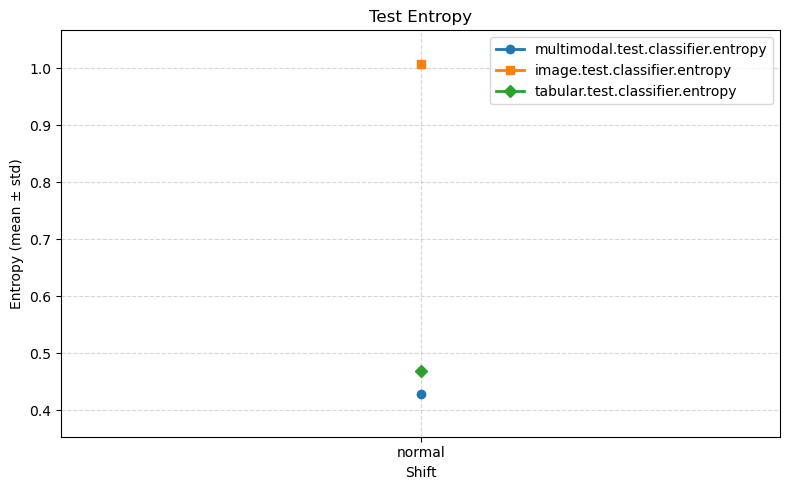

In [217]:
plot_one_grouped_df(summed_df_baseline_test, metrics=["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"], title="Test Entropy", metric_name="Entropy")

In [218]:
summed_df_baseline_test

multimodal.test.classifier.entropy          \
                                     mean     std   
Shift                                               
normal                           0.428167  0.0422   

       image.test.classifier.entropy            \
                                mean       std   
Shift                                            
normal                        1.0082  0.026096   

       tabular.test.classifier.entropy           multimodal.test.balanced_acc  \
                                  mean       std                         mean   
Shift                                                                           
normal                        0.468269  0.038924                     0.750657   

                 image.test.balanced_acc            ... test.acc_imaging       \
             std                    mean       std  ...             mean  std   
Shift                                               ...                         
normal  0.011768                     0.6  0.328244  ...         0.493333  0.0   

       test.auc_imaging           test.acc_tabular           test.auc_tabular  \
                   mean       std             mean       std             mean   
Shift                                                                           
normal         0.550272  0.028522           0.8408  0.009704         0.908031   

                 Seed       
             std mean  std  
Shift                       
normal  0.004674  inf  0.0  

[1 rows x 32 columns]

In [219]:
summed_df_baseline_test["test.acc"]

,mean,std
Shift,,
normal,0.839093,0.00695


In [220]:
baseline_path = os.path.join(BASE_PATH, "smaller_dataset/baseline")
df_baseline_eval = create_one_group_df(dir_path=baseline_path, filename="eval")
df_baseline_eval =  make_df_numeric(df=df_baseline_eval[["Shift", "multimodal.classifier.entropy", "image.classifier.entropy", "tabular.classifier.entropy", "classifier.multi.acc", "classifier.image.acc", "classifier.tab.acc", "multimodal.train.case1_ratio", "multimodal.train.case2_i_ratio", "multimodal.train.case2_t_ratio", "multimodal.train.case3_ratio"]])
summed_df_baseline_eval = summarize_df(df=df_baseline_eval, group_col="Shift")
summed_df_baseline_eval

multimodal.classifier.entropy           image.classifier.entropy  \
                                mean       std                     mean   
Shift                                                                     
TE                           0.57631  0.020011                  1.02581   
age                          0.52803  0.010485                  1.03490   
normal                       0.55597  0.004103                  1.04093   
weight                       0.55399  0.012868                  1.02716   

                 tabular.classifier.entropy           classifier.multi.acc  \
             std                       mean       std                 mean   
Shift                                                                        
TE      0.005789                    0.58821  0.018710              0.75895   
age     0.015370                    0.53323  0.019364              0.78243   
normal  0.001604                    0.56902  0.002199              0.76618   
weight  0.013888                    0.56079  0.017833              0.76480   

                 classifier.image.acc           classifier.tab.acc            \
             std                 mean       std               mean       std   
Shift                                                                          
TE      0.006508              0.48709  0.000601            0.76121  0.008292   
age     0.025493              0.46055  0.005453            0.77701  0.019963   
normal  0.004263              0.48281  0.003635            0.76711  0.002360   
weight  0.005666              0.48727  0.001170            0.76646  0.006717   

       multimodal.train.case1_ratio           multimodal.train.case2_i_ratio  \
                               mean       std                           mean   
Shift                                                                          
TE                          0.51830  0.012989                        0.02537   
age                         0.50094  0.009990                        0.02317   
normal                      0.49700  0.006235                        0.01850   
weight                      0.52641  0.021601                        0.01947   

                 multimodal.train.case2_t_ratio            \
             std                           mean       std   
Shift                                                       
TE      0.008804                        0.42779  0.004821   
age     0.007838                        0.45944  0.010239   
normal  0.004159                        0.46224  0.005801   
weight  0.007004                        0.43185  0.024652   

       multimodal.train.case3_ratio            
                               mean       std  
Shift                                          
TE                          0.02856  0.004137  
age                         0.01645  0.006353  
normal                      0.02224  0.003888  
weight                      0.02229  0.008437

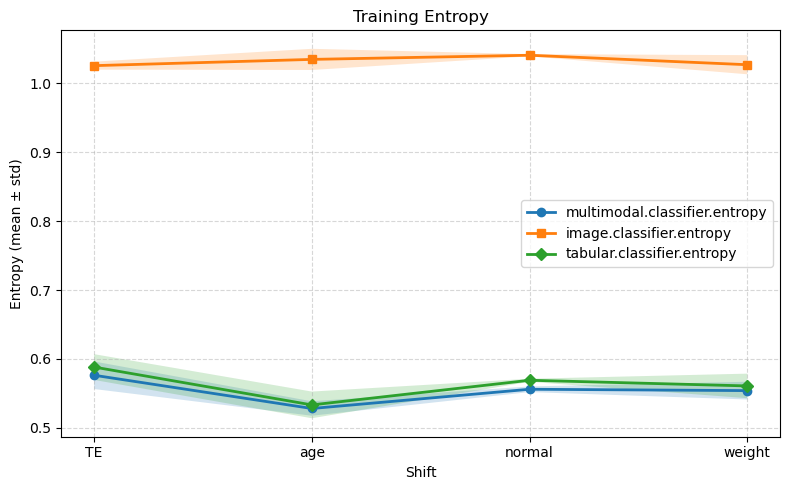

In [221]:
plot_one_grouped_df(summed_df_baseline_eval, metrics=["multimodal.classifier.entropy", "image.classifier.entropy", "tabular.classifier.entropy"], title="Training Entropy", metric_name="Entropy")

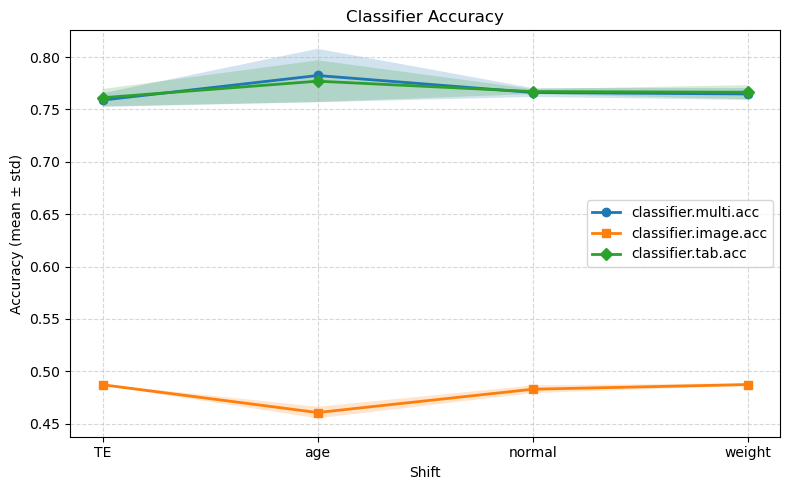

In [222]:
plot_one_grouped_df(summed_df_baseline_eval, metrics=["classifier.multi.acc", "classifier.image.acc", "classifier.tab.acc"], title="Classifier Accuracy", metric_name="Accuracy")

In [223]:
summed_df_baseline_eval[["multimodal.train.case1_ratio", "multimodal.train.case2_i_ratio", "multimodal.train.case2_t_ratio", "multimodal.train.case3_ratio"]]

multimodal.train.case1_ratio           multimodal.train.case2_i_ratio  \
                               mean       std                           mean   
Shift                                                                          
TE                          0.51830  0.012989                        0.02537   
age                         0.50094  0.009990                        0.02317   
normal                      0.49700  0.006235                        0.01850   
weight                      0.52641  0.021601                        0.01947   

                 multimodal.train.case2_t_ratio            \
             std                           mean       std   
Shift                                                       
TE      0.008804                        0.42779  0.004821   
age     0.007838                        0.45944  0.010239   
normal  0.004159                        0.46224  0.005801   
weight  0.007004                        0.43185  0.024652   

       multimodal.train.case3_ratio            
                               mean       std  
Shift                                          
TE                          0.02856  0.004137  
age                         0.01645  0.006353  
normal                      0.02224  0.003888  
weight                      0.02229  0.008437

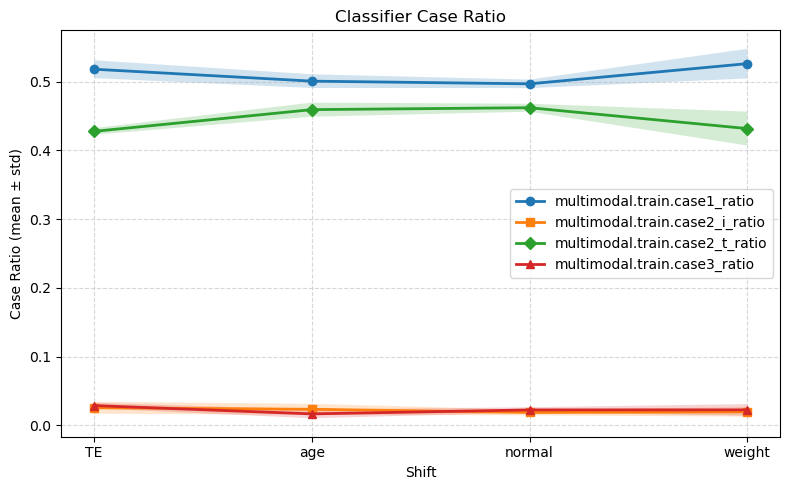

In [224]:
plot_one_grouped_df(summed_df_baseline_eval, metrics=["multimodal.train.case1_ratio", "multimodal.train.case2_i_ratio", "multimodal.train.case2_t_ratio", "multimodal.train.case3_ratio"], title="Classifier Case Ratio", metric_name="Case Ratio")

## Trainable Consent

### Keep all Embedding parts & contribute to classifier loss

#### Loss

$$
\mathcal{L} = \alpha \left(\mathcal{L}_{ce}(y_{m}, y) + \mathcal{L}_{ce}(y_{i}, y) + \mathcal{L}_{ce}(y_{t}, y)\right)+ \beta \left(\mathcal{L}_{CLIP}(feat_{i}, feat_{t})\right) + \gamma \left(\mathcal{L}^{i}_{ds} + \mathcal{L}^{t}_{ds}\right) + \epsilon \left( \mathcal{L}_{ce}(y^{*}, y) \right)
$$

where:

- $\mathcal{L}_{ce} = \text{Cross-Entropy Loss}$
- $\mathcal{L}_{CLIP} = \text{CLIP Loss}$
- $\mathcal{L}_{ds} = \text{CLUB Loss}$
- $\alpha = 0.2$ 
- $\beta = 3.0$ 
- $\gamma = 0.5$ 
- $\epsilon = [0, 0.1, 0.5, 1.0, 2.0, 3.0, 4.0]$

In [225]:
consent_path = os.path.join(BASE_PATH, "smaller_dataset/train_consent")
group_col = "epsilon"
df_c = create_two_group_df(dir_path=consent_path, filename="test", group_col=group_col, exp_name="consent")
summed_c_df = summarize_two_groups_df(df=df_c, first_group_col=group_col, second_group_col="Shift")

,mean,std
Shift,,
normal,0.839093,0.00695


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


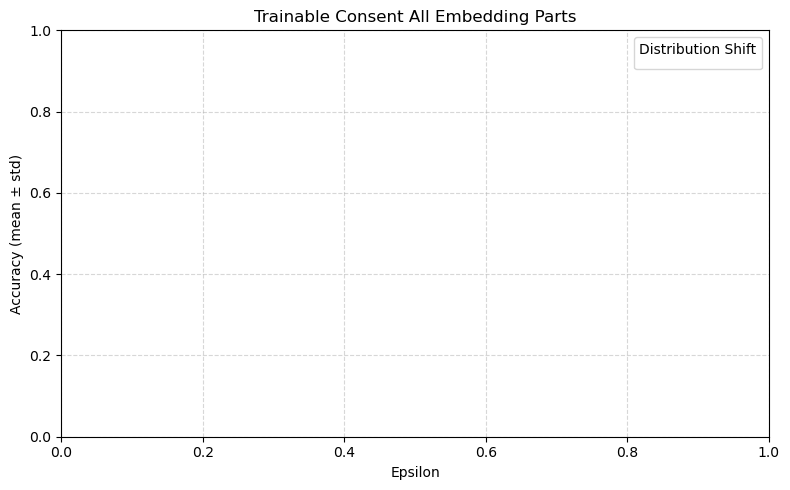

In [226]:
display(summed_df_baseline_test["test.acc"])
plot_two_grouped_df(df=summed_c_df, first_group_col=group_col, second_group_col="Shift", metric="test.acc", title="Trainable Consent All Embedding Parts")

### Only keep refined Embeddings & contribute to classifier loss

In [227]:
refined_path = os.path.join(BASE_PATH, "smaller_dataset/train_consent_cut")
group_col = "epsilon"
df_c_keep = create_two_group_df(dir_path=refined_path, filename="test", group_col=group_col, exp_name="consent")
summed_c_keep_df = summarize_two_groups_df(df=df_c_keep, first_group_col=group_col, second_group_col="Shift")

,mean,std
Shift,,
normal,0.839093,0.00695


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


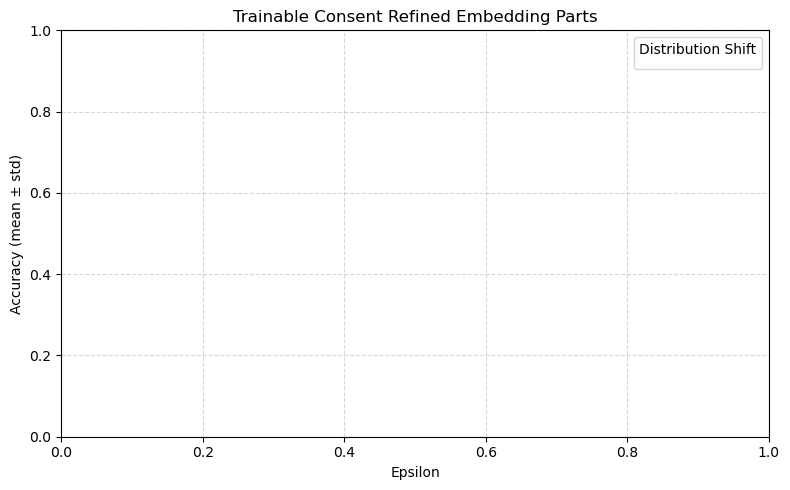

In [228]:
display(summed_df_baseline_test["test.acc"])
plot_two_grouped_df(df=summed_c_keep_df, first_group_col=group_col, second_group_col="Shift", metric="test.acc", title="Trainable Consent Refined Embedding Parts")

### Keep all Embedding parts & Replace CE Classifier Loss

$$
\mathcal{L} = \beta \left(\mathcal{L}_{CLIP}(feat_{i}, feat_{t})\right) + \gamma \left(\mathcal{L}^{i}_{ds} + \mathcal{L}^{t}_{ds}\right) + \epsilon \left( \mathcal{L}_{ce}(y^{*}, y) \right)
$$

where:

- $\mathcal{L}_{ce} = \text{Cross-Entropy Loss}$
- $\mathcal{L}_{CLIP} = \text{CLIP Loss}$
- $\mathcal{L}_{ds} = \text{CLUB Loss}$
- $\beta = 3.0$ 
- $\gamma = 0.5$ 
- $\epsilon = [0, 0.1, 0.5, 1.0, 2.0, 3.0, 4.0]$

In [229]:
loss_path = os.path.join(BASE_PATH, "smaller_dataset/train_consent_loss")
group_col = "epsilon"
df_c_loss = create_two_group_df(dir_path=loss_path, filename="test", group_col=group_col, exp_name="consent")
summed_c_loss_df = summarize_two_groups_df(df=df_c_loss, first_group_col=group_col, second_group_col="Shift")

,mean,std
Shift,,
normal,0.839093,0.00695


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


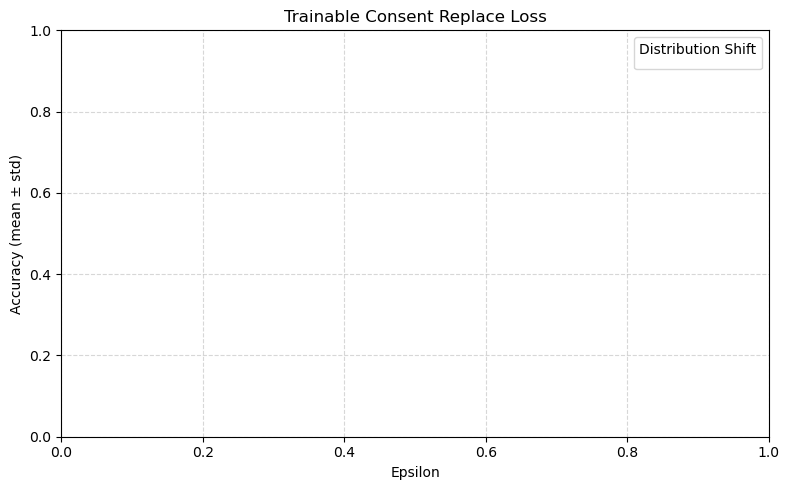

In [230]:
display(summed_df_baseline_test["test.acc"])
plot_two_grouped_df(df=summed_c_loss_df, first_group_col=group_col, second_group_col="Shift", metric="test.acc", title="Trainable Consent Replace Loss")

## Mixture of Experts

#### Loss

$$
\mathcal{L} = \alpha \left(\mathcal{L}_{ce}(y_{m}, y) + \mathcal{L}_{ce}(y_{i}, y) + \mathcal{L}_{ce}(y_{t}, y)\right)+ \beta \left(\mathcal{L}_{CLIP}(feat_{i}, feat_{t})\right) + \gamma \left(\mathcal{L}^{i}_{ds} + \mathcal{L}^{t}_{ds}\right) + \epsilon \left( \mathcal{L}_{MoE}(y^{*}, y) + \mathcal{L}_{ce}(y^{*}, y)\right)
$$

where:

- $\mathcal{L}_{ce} = \text{Cross-Entropy Loss}$
- $\mathcal{L}_{CLIP} = \text{CLIP Loss}$
- $\mathcal{L}_{ds} = \text{CLUB Loss}$
- $\mathcal{L}_{MoE} = \text{Load Balancing Loss}$
- $\alpha = 0.2$ 
- $\beta = 3.0$ 
- $\gamma = 0.5$ 
- $\epsilon = [0, 0.1, 0.5, 1.0, 2.0, 3.0, 4.0]$

#### Classifier Input

- Gate: $\mathcal{z}^{i}_{c} + \mathcal{z}_{s} + \mathcal{z}^{t}_{c}$
- Multimodal: $\mathcal{z}^{i}_{c} + \mathcal{z}_{s} + \mathcal{z}^{t}_{c}$
- Imaging: $\mathcal{z}^{i}_{c}$
- Tabular: $\mathcal{z}^{t}_{c}$

#### k = 1

In [231]:
moe_path = os.path.join(BASE_PATH, "smaller_dataset/MoE_1_cut")
group_col = "epsilon"
df_c_moe = create_two_group_df(dir_path=moe_path, filename="test", group_col=group_col, exp_name="MoE")
summed_c_moe_df = summarize_two_groups_df(df=df_c_moe, first_group_col=group_col, second_group_col="Shift")

,mean,std
Shift,,
normal,0.839093,0.00695


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


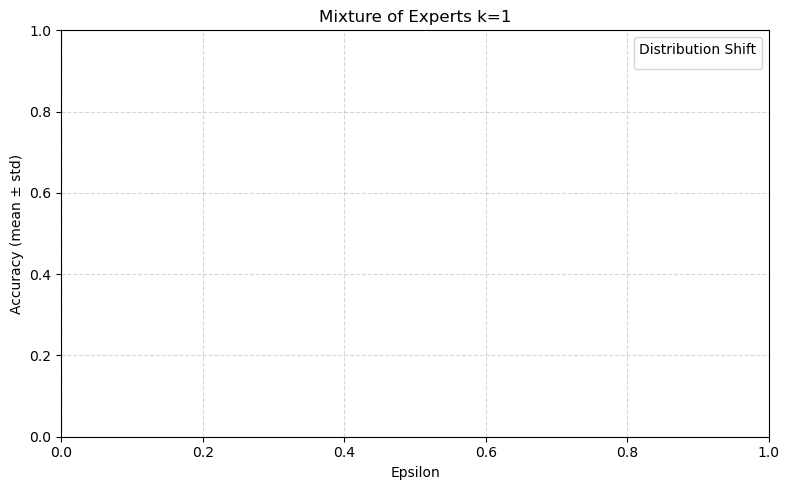

In [232]:
display(summed_df_baseline_test["test.acc"])
plot_two_grouped_df(df=summed_c_moe_df, first_group_col=group_col, second_group_col="Shift", metric="test.acc", title="Mixture of Experts k=1")

#### k = 2

In [233]:
moe_2_path = os.path.join(BASE_PATH, "smaller_dataset/MoE_2_cut")
group_col = "epsilon"
df_c_moe_2 = create_two_group_df(dir_path=moe_2_path, filename="test", group_col=group_col, exp_name="MoE")
summed_c_moe_2_df = summarize_two_groups_df(df=df_c_moe_2, first_group_col=group_col, second_group_col="Shift")

,mean,std
Shift,,
normal,0.839093,0.00695


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


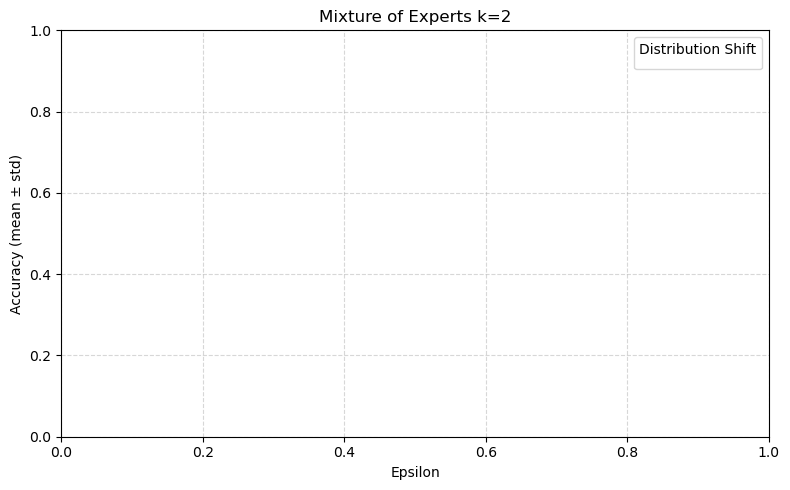

In [234]:
display(summed_df_baseline_test["test.acc"])
plot_two_grouped_df(df=summed_c_moe_2_df, first_group_col=group_col, second_group_col="Shift", metric="test.acc", title="Mixture of Experts k=2")

#### k = 3


In [235]:
moe_3_path = os.path.join(BASE_PATH, "smaller_dataset/MoE_3_cut")
group_col = "epsilon"
df_c_moe_3 = create_two_group_df(dir_path=moe_3_path, filename="test", group_col=group_col, exp_name="MoE")
summed_c_moe_3_df = summarize_two_groups_df(df=df_c_moe_3, first_group_col=group_col, second_group_col="Shift")

,mean,std
Shift,,
normal,0.839093,0.00695


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


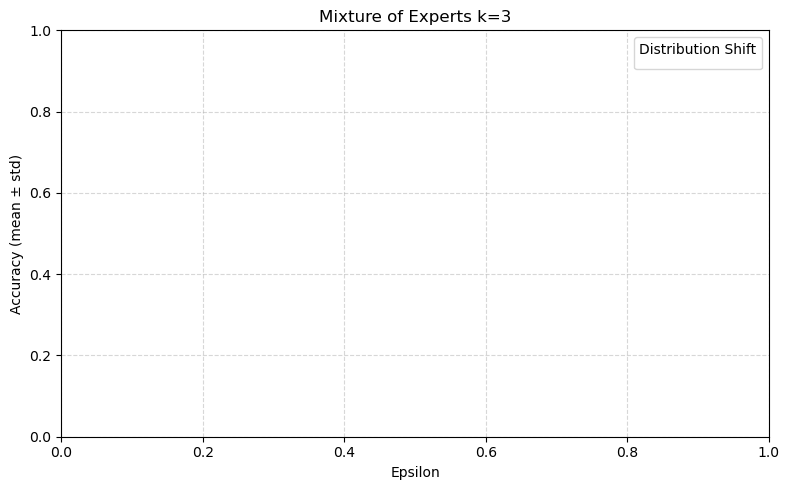

In [236]:
display(summed_df_baseline_test["test.acc"])
plot_two_grouped_df(df=summed_c_moe_3_df, first_group_col=group_col, second_group_col="Shift", metric="test.acc", title="Mixture of Experts k=3")

#### Classifier Input

- Gate: $\mathcal{z}^{i}_{c} + \mathcal{z}_{s} + \mathcal{z}^{t}_{c}$
- Multimodal: $\mathcal{z}^{i}_{c} + \mathcal{z}_{s} + \mathcal{z}^{t}_{c}$
- Imaging: $\mathcal{z}^{i}_{c} + \mathcal{z}^{i}_{s}$
- Tabular: $\mathcal{z}^{t}_{c} + \mathcal{z}^{t}_{s}$

#### k = 1

## Bigger Dataset (removed GDTOTAL)

### Baseline

In [237]:
nogd_b_path = os.path.join(BASE_PATH, "smaller_dataset/batch_size_no_GDTOTAL")
group_col = "epsilon"
df_c_nogd_b = create_one_group_df(dir_path=nogd_b_path, filename="test", batchsize=True)
#summed_c_nogd_b_df = summarize_df(df=df_c_nogd_b, group_col="BatchSize")
#summed_c_nogd_b_df

In [238]:
#summed_c_nogd_b_df[["test.acc", "test.balanced_acc"]]

## Final Dataset

In [239]:
import re

def format_latex_table(raw: str) -> str:
    lines = raw.strip().splitlines()

    data_rows = []
    for line in lines:
        line = line.strip()

        # Match data rows like: 32 & 0.8409 $\pm$ 0.0015 & ...
        match = re.match(
            r"(\d+)\s*&\s*([\d.]+)\s*\\pm\s*([\d.]+)\s*&\s*([\d.]+)\s*\\pm\s*([\d.]+)",
            line
        )
        if match:
            bs, acc, acc_std, bal, bal_std = match.groups()

            row = (
                f"{bs} & "
                f"{float(acc):.4f} $\\pm$ {float(acc_std):.3f} & "
                f"{float(bal):.4f} $\\pm$ {float(bal_std):.3f} \\\\"
            )
            data_rows.append(row)

    table = [
        r"\begin{table}",
        r"\centering",
        r"\begin{tabular}{lll}",
        r"\hline",
        r"Batch Size & Accuracy & Balanced Accuracy \\",
        r"\hline",
        *data_rows,
        r"\hline",
        r"\end{tabular}",
        r"\end{table}",
    ]

    return "\n".join(table)

In [240]:
def convert_to_latex(df: pd.DataFrame):
    df_fmt = df.copy()
    df_fmt[("test.acc", "mean")] = (
        df[("test.acc", "mean")].map("{:.4f}".format)
        + " $\\pm$ "
        + df[("test.acc", "std")].map("{:.4f}".format)
    )
    
    df_fmt[("test.balanced_acc", "mean")] = (
        df[("test.balanced_acc", "mean")].map("{:.4f}".format)
        + " $\\pm$ "
        + df[("test.balanced_acc", "std")].map("{:.4f}".format)
    )
    
    df_final = df_fmt.drop(columns=[
        ("test.acc", "std"),
        ("test.balanced_acc", "std")
    ])
    
    print(df_final.to_latex(escape=False))

### Batchsize

In [241]:
f_batch_path = os.path.join(BASE_PATH, "final_dataset/baseline")
group_col = "epsilon"
df_c_f_batch = create_one_group_df(dir_path=f_batch_path, filename="test", batchsize=True, one_per_seed=True)
display(df_c_f_batch)
df_c_f_batch["BatchSize"] = pd.to_numeric(df_c_f_batch["BatchSize"], errors='coerce')
summed_f_batch_df = summarize_df(df=df_c_f_batch, group_col="BatchSize")
summed_f_batch_df[["test.acc", "test.balanced_acc"]]

,multimodal.test.classifier.entropy,image.test.classifier.entropy,tabular.test.classifier.entropy,multimodal.test.balanced_acc,image.test.balanced_acc,tabular.test.balanced_acc,test.balanced_acc,test.acc,test.auc,test.acc_multimodal,test.auc_multimodal,test.acc_imaging,test.auc_imaging,test.acc_tabular,test.auc_tabular,Shift,BatchSize,Seed
0,0.383552,1.013571,0.443369,0.744131,0.333333,0.747863,0.744131,0.842667,0.910134,0.842667,0.910134,0.493333,0.568392,0.834667,0.913198,normal,128,2024
1,0.497583,1.021189,0.515584,0.748056,0.333333,0.753291,0.748056,0.840000,0.905587,0.840000,0.905587,0.493333,0.545240,0.842667,0.902137,normal,32,2023
2,0.462028,0.987998,0.499091,0.739626,0.333333,0.730509,0.739626,0.840000,0.905828,0.840000,0.905828,0.493333,0.592936,0.834667,0.906937,normal,64,2024
3,0.404124,1.039006,0.449094,0.757862,0.333333,0.769673,0.757862,0.840000,0.900675,0.840000,0.900675,0.493333,0.492276,0.848000,0.902801,normal,128,2023
4,0.390851,0.994632,0.443143,0.752457,1.000000,0.744320,0.752457,0.845333,0.901349,0.845333,0.901349,0.493333,0.584650,0.842667,0.906297,normal,128,2022
5,0.439447,1.030051,0.475663,0.763507,1.000000,0.757664,0.763507,0.848000,0.906738,0.848000,0.906738,0.493333,0.554177,0.845333,0.908017,normal,256,2022
6,0.376837,1.072848,0.428300,0.752120,0.333333,0.771457,0.752120,0.842667,0.910475,0.842667,0.910475,0.493333,0.478633,0.832000,0.911230,normal,32,2024
7,0.398586,1.018471,0.448484,0.772234,1.000000,0.776298,0.772234,0.840000,0.905285,0.840000,0.905285,0.493333,0.562889,0.842667,0.905400,normal,32,2022
8,0.496994,1.004714,0.545843,0.754650,1.000000,0.767706,0.754650,0.837333,0.914836,0.837333,0.914836,0.493333,0.597778,0.850667,0.913253,normal,64,2022
9,0.469331,0.941187,0.488657,0.763430,0.333333,0.766393,0.763430,0.848000,0.907898,0.848000,0.907898,0.493333,0.571680,0.848000,0.906865,normal,64,2023


/tmp/ipykernel_1856418/1263068295.py:7: FutureWarning: ['Shift'] did not aggregate successfully. If any error is raised this will raise in a future version of pandas. Drop these columns/ops to avoid this warning.
  return make_df_numeric(df).groupby(group_col).agg(['mean', 'std'])


test.acc           test.balanced_acc          
               mean       std              mean       std
BatchSize                                                
32         0.840889  0.001540          0.757470  0.012946
64         0.841778  0.005551          0.752569  0.012038
128        0.842667  0.002667          0.751483  0.006917
256        0.845333  0.003771          0.756859  0.009402

In [242]:
convert_to_latex(df=summed_f_batch_df[["test.acc", "test.balanced_acc"]])

\begin{tabular}{lll}
\toprule
{} &             test.acc &    test.balanced_acc \\
{} &                 mean &                 mean \\
BatchSize &                      &                      \\
\midrule
32        &  0.8409 $\pm$ 0.0015 &  0.7575 $\pm$ 0.0129 \\
64        &  0.8418 $\pm$ 0.0056 &  0.7526 $\pm$ 0.0120 \\
128       &  0.8427 $\pm$ 0.0027 &  0.7515 $\pm$ 0.0069 \\
256       &  0.8453 $\pm$ 0.0038 &  0.7569 $\pm$ 0.0094 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_1856418/1891150706.py:20: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(df_final.to_latex(escape=False))


### Baseline

In [243]:
f_base_path = os.path.join(BASE_PATH, "final_dataset/batchsize")
group_col = "epsilon"
df_c_f_base = create_one_group_df(dir_path=f_base_path, filename="test", one_per_seed=True)
display(df_c_f_base["Shift"].value_counts())
summed_f_base_df = summarize_df(df=df_c_f_base, group_col="Shift")
summed_f_base_df[["test.acc", "test.balanced_acc"]]

age       3
weight    3
TE        3
normal    3
Name: Shift, dtype: int64

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.852444  0.009365          0.819313  0.012563
age     0.818667  0.016000          0.818361  0.009531
normal  0.840000  0.002667          0.752783  0.004264
weight  0.854222  0.007698          0.841267  0.022204

In [244]:
convert_to_latex(df=summed_f_base_df[["test.acc", "test.balanced_acc"]])

\begin{tabular}{lll}
\toprule
{} &             test.acc &    test.balanced_acc \\
{} &                 mean &                 mean \\
Shift  &                      &                      \\
\midrule
TE     &  0.8524 $\pm$ 0.0094 &  0.8193 $\pm$ 0.0126 \\
age    &  0.8187 $\pm$ 0.0160 &  0.8184 $\pm$ 0.0095 \\
normal &  0.8400 $\pm$ 0.0027 &  0.7528 $\pm$ 0.0043 \\
weight &  0.8542 $\pm$ 0.0077 &  0.8413 $\pm$ 0.0222 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_1856418/1891150706.py:20: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(df_final.to_latex(escape=False))


In [245]:
def plot_results(path: str, group_col: str, filename: str, second_group_col: str, exp_name: str, metric: Union[str, list[str]], title: str, pattern: str = r"{exp_name}_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_)?([a-zA-Z]+)_final_seed", base_path:str=BASE_PATH, just_plot=False):
    moe_path = os.path.join(base_path, path)
    df_c_moe = create_two_group_df(dir_path=moe_path, filename=filename, group_col=group_col, exp_name=exp_name, pattern=pattern)
    summed_c_moe_df = summarize_two_groups_df(df=df_c_moe, first_group_col=group_col, second_group_col=second_group_col)
    moe_cols = [c for c in summed_c_moe_df.columns if str(c[0]).startswith('MoE.test.weight') or str(c[0]) in [group_col, second_group_col]]
    
    met_dict = {"multimodal.test.classifier.entropy": "$f_{m}$ Entropy",
                "image.test.classifier.entropy": "$f_{i}$ Entropy",
                "tabular.test.classifier.entropy": "$f_{t}$ Entropy",
                "test.acc": "Accuracy",
                "test.balanced_acc": "Balanced Accuracy",
                "test.expert_no0.entropy": "$f_{0}$ Entropy",
                "test.expert_no1.entropy": "$f_{1}$ Entropy",
                "test.expert_no2.entropy": "$f_{2}$ Entropy"}
    
    if moe_cols:
        moe_cols = [c for c in summed_c_moe_df.columns if str(c[0]).startswith('MoE.test.weight')]
        moe_mean_cols = summed_c_moe_df[moe_cols].xs('mean', axis=1, level=1)

        # Prepare a DataFrame to collect max rows
        max_rows = pd.DataFrame()
        extra_cols = [('Shift', ''), ('epsilon', '')]

        # Iterate over shifts
        for shift, group_df in summed_c_moe_df.groupby(('Shift', '')):
            if not just_plot:
                print(f"\nShift: {shift}")
            for col in moe_mean_cols.columns:
                max_val = group_df[col]['mean'].max()  # max value for this weight in this shift
                rows = group_df[group_df[col]['mean'] == max_val]  # rows reaching the max
                if not just_plot:
                    print(f"{col} max value: {max_val}")
                #display(rows)
                # Optionally collect all rows
                max_rows = pd.concat([max_rows, rows])
        if not just_plot:
            display(max_rows[extra_cols + moe_cols])
        #display(summed_c_moe_df[extra_cols + moe_cols])

    metric_list = metric if isinstance(metric, list) else  [metric]
    for met in metric_list:
        met_name = met_dict[met]
        t = title + f" [{met_name}]"
        plot_two_grouped_df(df=summed_c_moe_df, first_group_col=group_col, second_group_col=second_group_col, metric=met, title=t)
    
    if not just_plot:
        display(summed_c_moe_df[["test.acc", "test.balanced_acc", group_col, second_group_col]])
        display(summed_f_base_df[["test.acc", "test.balanced_acc"]])

In [246]:
metric = ["test.balanced_acc"]

In [247]:
summed_f_base_df[["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy", "test.acc", "test.balanced_acc"]]  

multimodal.test.classifier.entropy            \
                                     mean       std   
Shift                                                 
TE                               0.451688  0.005861   
age                              0.548849  0.029364   
normal                           0.458434  0.073259   
weight                           0.502436  0.045353   

       image.test.classifier.entropy            \
                                mean       std   
Shift                                            
TE                          1.016213  0.034405   
age                         0.977101  0.004334   
normal                      1.030628  0.038214   
weight                      1.000474  0.020076   

       tabular.test.classifier.entropy            test.acc            \
                                  mean       std      mean       std   
Shift                                                                  
TE                            0.488810  0.023102  0.852444  0.009365   
age                           0.583696  0.033005  0.818667  0.016000   
normal                        0.497962  0.062017  0.840000  0.002667   
weight                        0.548109  0.068495  0.854222  0.007698   

       test.balanced_acc            
                    mean       std  
Shift                               
TE              0.819313  0.012563  
age             0.818361  0.009531  
normal          0.752783  0.004264  
weight          0.841267  0.022204

In [248]:
convert_to_latex(df=summed_f_base_df[["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy", "test.acc", "test.balanced_acc"]])

\begin{tabular}{lrrrrrrll}
\toprule
{} & \multicolumn{2}{l}{multimodal.test.classifier.entropy} & \multicolumn{2}{l}{image.test.classifier.entropy} & \multicolumn{2}{l}{tabular.test.classifier.entropy} &             test.acc &    test.balanced_acc \\
{} &                               mean &       std &                          mean &       std &                            mean &       std &                 mean &                 mean \\
Shift  &                                    &           &                               &           &                                 &           &                      &                      \\
\midrule
TE     &                           0.451688 &  0.005861 &                      1.016213 &  0.034405 &                        0.488810 &  0.023102 &  0.8524 $\pm$ 0.0094 &  0.8193 $\pm$ 0.0126 \\
age    &                           0.548849 &  0.029364 &                      0.977101 &  0.004334 &                        0.583696 &  0.033005 &  0.8187 $\p

/tmp/ipykernel_1856418/1891150706.py:20: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(df_final.to_latex(escape=False))


## MoE k=1 Linear


Shift: TE
MoE.test.weight0 max value: 0.5520000060399374
MoE.test.weight1 max value: 0.32711110264062876
MoE.test.weight2 max value: 0.4382222294807434

Shift: age
MoE.test.weight0 max value: 0.5795555512110392
MoE.test.weight1 max value: 0.19288888573646545
MoE.test.weight2 max value: 0.6275555690129598

Shift: normal
MoE.test.weight0 max value: 0.6088889042536417
MoE.test.weight1 max value: 0.33866667623321217
MoE.test.weight2 max value: 0.42577778299649555

Shift: weight
MoE.test.weight0 max value: 0.5244444410006205
MoE.test.weight1 max value: 0.09066666538516677
MoE.test.weight2 max value: 0.7271111011505127


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
12      TE       2         0.552000  0.100240         0.154667  0.242579   
8       TE       1         0.416889  0.270983         0.327111  0.466524   
0       TE     0.1         0.312889  0.267204         0.248889  0.401440   
1      age     0.1         0.579556  0.165942         0.018667  0.023702   
9      age       1         0.311111  0.238310         0.192889  0.265736   
5      age     0.5         0.326222  0.090876         0.046222  0.048099   
18  normal       3         0.608889  0.031251         0.080000  0.090784   
6   normal     0.5         0.334222  0.199810         0.338667  0.415316   
2   normal     0.1         0.266667  0.205645         0.307556  0.466738   
11  weight       1         0.524444  0.182766         0.085333  0.138590   
15  weight       2         0.310222  0.033342         0.090667  0.072000   
19  weight       3         0.219556  0.150952         0.053333  0.064056   

   MoE.test.weight2            
               mean       std  
12         0.293333  0.266306  
8          0.256000  0.230755  
0          0.438222  0.335982  
1          0.401778  0.158937  
9          0.496000  0.030753  
5          0.627556  0.072410  
18         0.311111  0.096234  
6          0.327111  0.292293  
2          0.425778  0.398328  
11         0.390222  0.295511  
15         0.599111  0.075629  
19         0.727111  0.166476

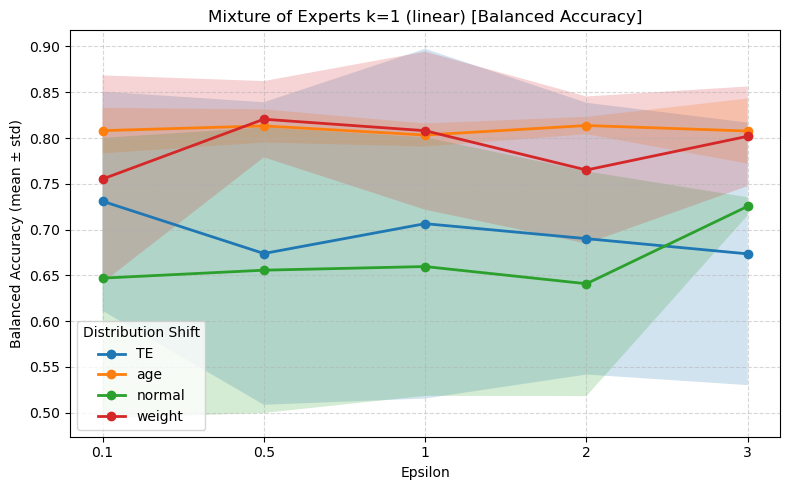

test.acc           test.balanced_acc           epsilon   Shift
        mean       std              mean       std                
0   0.792889  0.100110          0.730988  0.119724     0.1      TE
1   0.804444  0.013422          0.808095  0.024830     0.1     age
2   0.732444  0.161026          0.647033  0.153062     0.1  normal
3   0.814222  0.035511          0.755256  0.113205     0.1  weight
4   0.749333  0.166277          0.673909  0.165227     0.5      TE
5   0.807111  0.004073          0.813264  0.018088     0.5     age
6   0.732444  0.160938          0.655688  0.155959     0.5  normal
7   0.836444  0.015163          0.820591  0.041647     0.5  weight
8   0.747556  0.174057          0.706503  0.190976     1.0      TE
9   0.795556  0.029973          0.803278  0.012595     1.0     age
10  0.726222  0.167477          0.659668  0.141228     1.0  normal
11  0.834667  0.025716          0.808036  0.086298     1.0  weight
12  0.735111  0.162127          0.690139  0.148413     2.0      TE
13  0.805333  0.018667          0.813694  0.009430     2.0     age
14  0.729778  0.131300          0.640888  0.122732     2.0  normal
15  0.792889  0.041340          0.765109  0.080334     2.0  weight
16  0.726222  0.168957          0.673501  0.143357     3.0      TE
17  0.773333  0.063498          0.807680  0.035531     3.0     age
18  0.796444  0.033976          0.725494  0.009841     3.0  normal
19  0.781333  0.071901          0.801968  0.054363     3.0  weight

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.852444  0.009365          0.819313  0.012563
age     0.818667  0.016000          0.818361  0.009531
normal  0.840000  0.002667          0.752783  0.004264
weight  0.854222  0.007698          0.841267  0.022204

In [249]:
plot_results(path="final_dataset/MoE1-linear", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=metric, title="Mixture of Experts k=1 (linear)", just_plot=False)

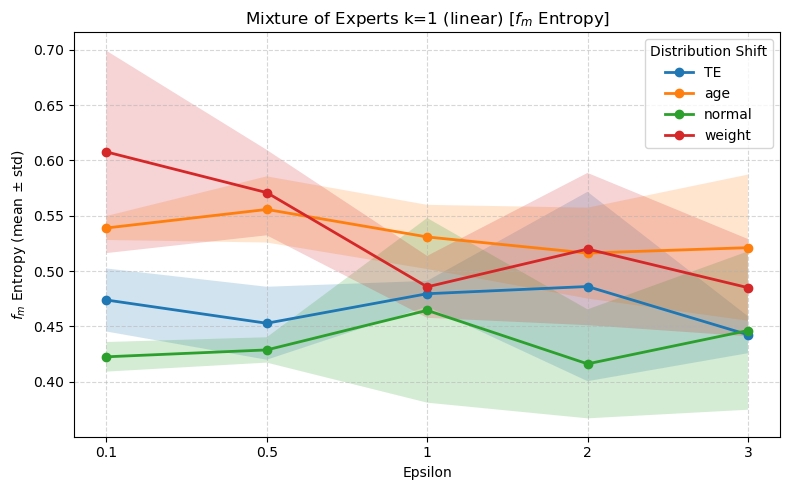

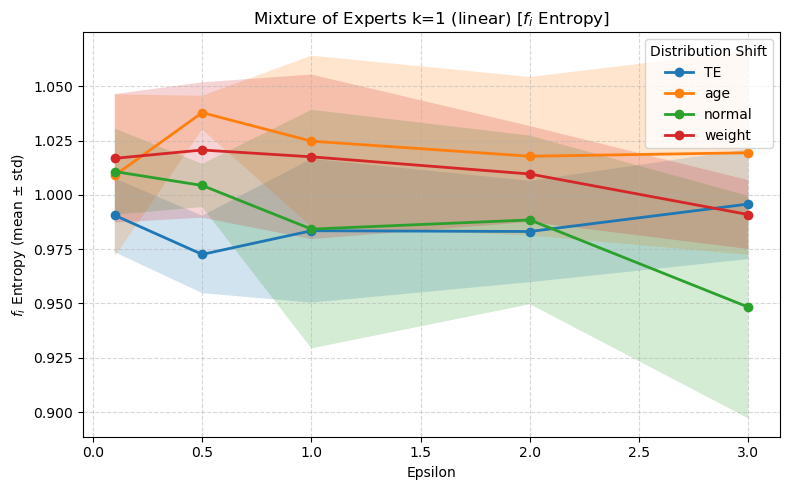

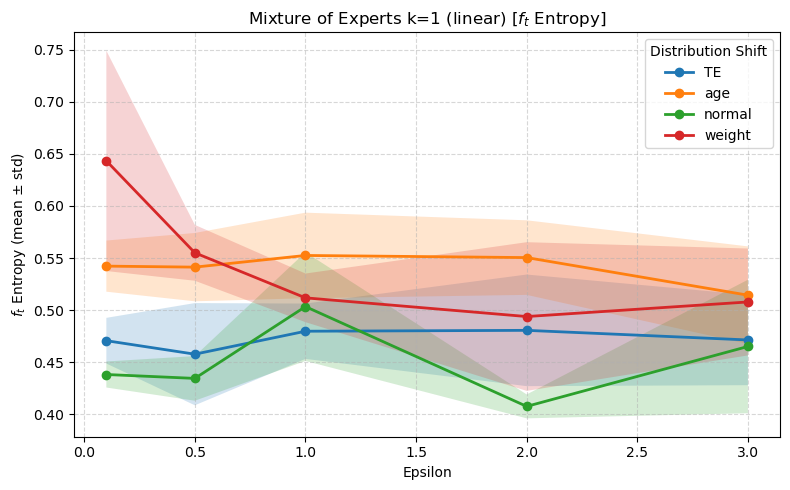

In [250]:
plot_results(path="final_dataset/MoE1-linear", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True)

## MoE k=1 MLP


Shift: TE
MoE.test.weight0 max value: 0.5795555549363295
MoE.test.weight1 max value: 0.2977777767616014
MoE.test.weight2 max value: 0.3760000119606654

Shift: age
MoE.test.weight0 max value: 0.5724444488684336
MoE.test.weight1 max value: 0.36266666650772095
MoE.test.weight2 max value: 0.21688888718684507

Shift: normal
MoE.test.weight0 max value: 0.5484444499015808
MoE.test.weight1 max value: 0.2871111035346985
MoE.test.weight2 max value: 0.27466666636367637

Shift: weight
MoE.test.weight0 max value: 0.2711111133297284
MoE.test.weight1 max value: 0.21511110663414001
MoE.test.weight2 max value: 0.702222208182017


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
16      TE       3         0.579556  0.487091         0.297778  0.513459   
16      TE       3         0.579556  0.487091         0.297778  0.513459   
8       TE       1         0.497778  0.460758         0.126222  0.218623   
1      age     0.1         0.572444  0.408073         0.232000  0.203664   
13     age       2         0.423111  0.499602         0.362667  0.369514   
17     age       3         0.509333  0.420801         0.273778  0.306775   
2   normal     0.1         0.548444  0.501619         0.202667  0.178905   
18  normal       3         0.511111  0.458964         0.287111  0.260793   
10  normal       1         0.529778  0.468737         0.195556  0.169377   
19  weight       3         0.271111  0.368486         0.139556  0.122502   
7   weight     0.5         0.201778  0.342585         0.215111  0.193776   
11  weight       1         0.231111  0.400296         0.066667  0.075941   

   MoE.test.weight2            
               mean       std  
16         0.122667  0.083820  
16         0.122667  0.083820  
8          0.376000  0.267585  
1          0.195556  0.231345  
13         0.214222  0.267948  
17         0.216889  0.114055  
2          0.248889  0.417308  
18         0.201778  0.256088  
10         0.274667  0.375072  
19         0.589333  0.245985  
7          0.583111  0.163872  
11         0.702222  0.346095

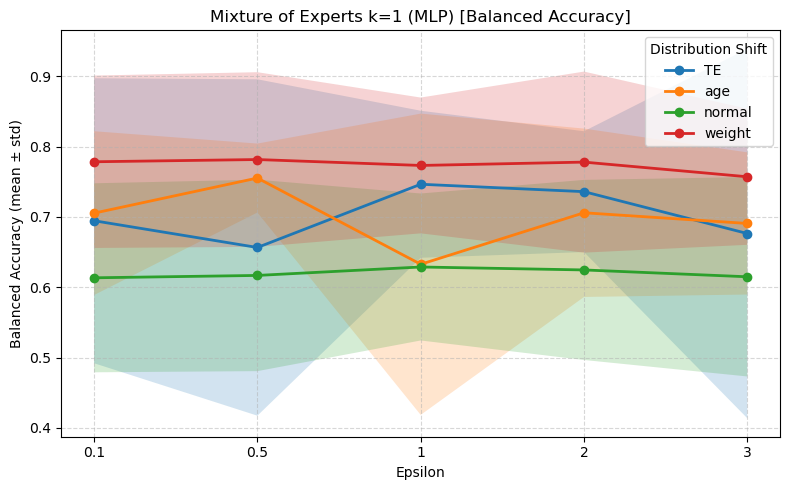

test.acc           test.balanced_acc           epsilon   Shift
        mean       std              mean       std                
0   0.774222  0.127787          0.694545  0.202565     0.1      TE
1   0.775111  0.028514          0.705336  0.116453     0.1     age
2   0.707556  0.150291          0.613407  0.134351     0.1  normal
3   0.827556  0.051731          0.778374  0.122540     0.1  weight
4   0.741333  0.166619          0.656516  0.239138     0.5      TE
5   0.791111  0.009365          0.755239  0.048997     0.5     age
6   0.706667  0.145498          0.616780  0.136072     0.5  normal
7   0.828444  0.050055          0.781551  0.124159     0.5  weight
8   0.832889  0.033766          0.746405  0.104535     1.0      TE
9   0.754667  0.057007          0.632662  0.214160     1.0     age
10  0.742222  0.124575          0.628776  0.104472     1.0  normal
11  0.821333  0.053930          0.773131  0.096527     1.0  weight
12  0.835556  0.024197          0.735879  0.085878     2.0      TE
13  0.789333  0.028095          0.705872  0.119688     2.0     age
14  0.738667  0.138590          0.624584  0.128010     2.0  normal
15  0.825778  0.050479          0.777894  0.128704     2.0  weight
16  0.743111  0.168007          0.676353  0.262618     3.0      TE
17  0.737778  0.055575          0.690681  0.101051     3.0     age
18  0.710222  0.150904          0.614870  0.141730     3.0  normal
19  0.828444  0.054802          0.757055  0.096732     3.0  weight

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.852444  0.009365          0.819313  0.012563
age     0.818667  0.016000          0.818361  0.009531
normal  0.840000  0.002667          0.752783  0.004264
weight  0.854222  0.007698          0.841267  0.022204

In [251]:
plot_results(path="final_dataset/MoE1-MLP", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=metric, title="Mixture of Experts k=1 (MLP)")

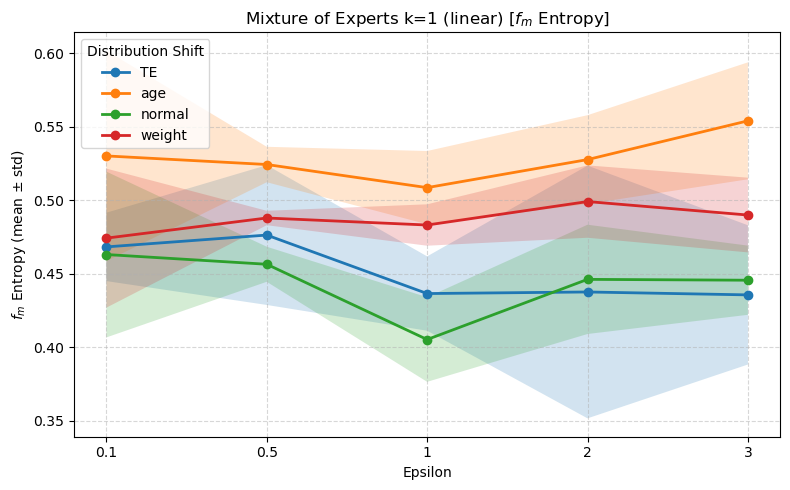

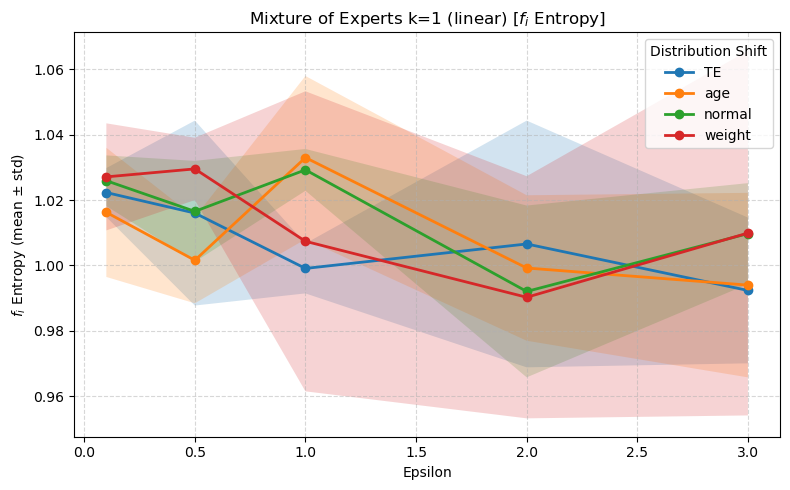

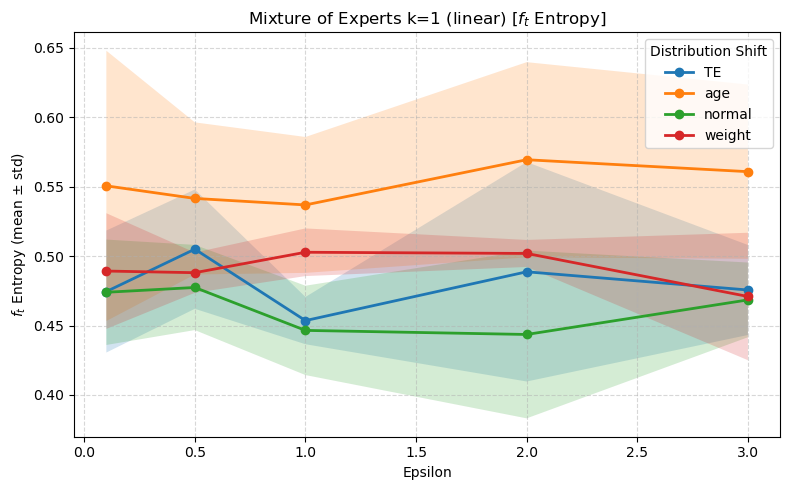

In [252]:
plot_results(path="final_dataset/MoE1-MLP", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True)

## MoE k=2 linear


Shift: TE
MoE.test.weight0 max value: 0.3618147273858388
MoE.test.weight1 max value: 0.3440180122852325
MoE.test.weight2 max value: 0.43936432401339215

Shift: age
MoE.test.weight0 max value: 0.31105600794156385
MoE.test.weight1 max value: 0.4200569788614908
MoE.test.weight2 max value: 0.4211178620656331

Shift: normal
MoE.test.weight0 max value: 0.41251835227012634
MoE.test.weight1 max value: 0.40761415163675946
MoE.test.weight2 max value: 0.33982832233111065

Shift: weight
MoE.test.weight0 max value: 0.38463910420735675
MoE.test.weight1 max value: 0.3164559304714203
MoE.test.weight2 max value: 0.4221359093983968


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
12      TE       2         0.361815  0.068816         0.320349  0.031073   
16      TE       3         0.334605  0.047115         0.344018  0.037930   
0       TE     0.1         0.292993  0.033247         0.267643  0.038337   
5      age     0.5         0.311056  0.051528         0.352454  0.077019   
17     age       3         0.284948  0.068680         0.420057  0.017562   
1      age     0.1         0.256043  0.073876         0.322839  0.045230   
2   normal     0.1         0.412518  0.014119         0.287764  0.058659   
14  normal       2         0.254601  0.050589         0.407614  0.055641   
6   normal     0.5         0.324802  0.079680         0.335370  0.023062   
19  weight       3         0.384639  0.053768         0.278042  0.035392   
15  weight       2         0.321484  0.037470         0.316456  0.024717   
3   weight     0.1         0.336711  0.091423         0.241153  0.018372   

   MoE.test.weight2            
               mean       std  
12         0.317837  0.078118  
16         0.321377  0.041434  
0          0.439364  0.014687  
5          0.336490  0.068140  
17         0.294995  0.052753  
1          0.421118  0.069663  
2          0.299718  0.067670  
14         0.337785  0.071627  
6          0.339828  0.058413  
19         0.337319  0.087410  
15         0.362060  0.062102  
3          0.422136  0.109653

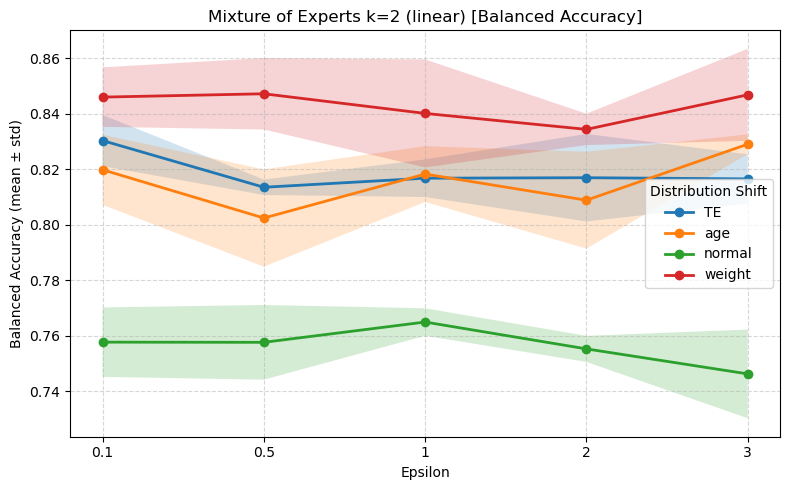

test.acc           test.balanced_acc           epsilon   Shift
        mean       std              mean       std                
0   0.852444  0.001540          0.830309  0.009207     0.1      TE
1   0.813333  0.018667          0.819800  0.012624     0.1     age
2   0.841778  0.008572          0.757704  0.012496     0.1  normal
3   0.855111  0.003079          0.845963  0.010713     0.1  weight
4   0.848889  0.004073          0.813491  0.002786     0.5      TE
5   0.803556  0.004073          0.802409  0.017522     0.5     age
6   0.826667  0.030052          0.757639  0.013448     0.5  normal
7   0.856000  0.004619          0.847166  0.012864     0.5  weight
8   0.845333  0.004619          0.816755  0.006771     1.0      TE
9   0.809778  0.008572          0.818245  0.010054     1.0     age
10  0.831111  0.013422          0.764948  0.004952     1.0  normal
11  0.845333  0.009615          0.840090  0.019445     1.0  weight
12  0.848000  0.002667          0.816931  0.015768     2.0      TE
13  0.808889  0.010777          0.808833  0.017441     2.0     age
14  0.825778  0.010777          0.755276  0.004692     2.0  normal
15  0.848000  0.000000          0.834340  0.005644     2.0  weight
16  0.847111  0.006158          0.816512  0.008852     3.0      TE
17  0.802667  0.012220          0.829005  0.003541     3.0     age
18  0.825778  0.013422          0.746266  0.015974     3.0  normal
19  0.848889  0.010777          0.846787  0.016575     3.0  weight

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.852444  0.009365          0.819313  0.012563
age     0.818667  0.016000          0.818361  0.009531
normal  0.840000  0.002667          0.752783  0.004264
weight  0.854222  0.007698          0.841267  0.022204

In [253]:
plot_results(path="final_dataset/MoE2-linear", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=metric, title="Mixture of Experts k=2 (linear)")

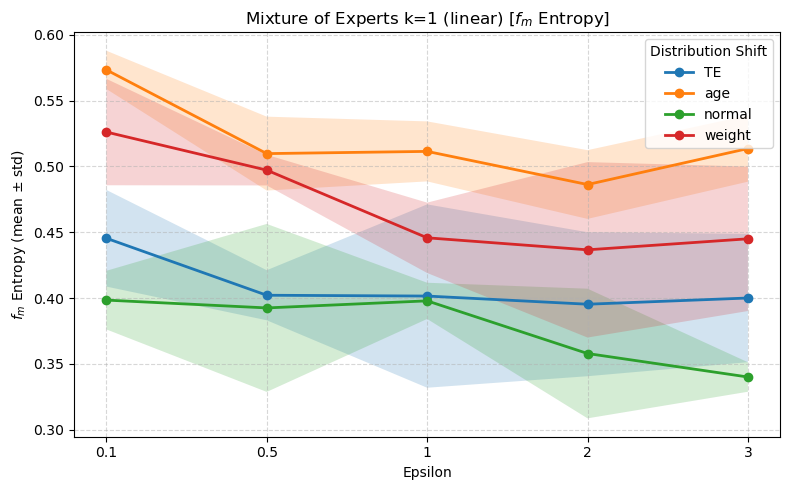

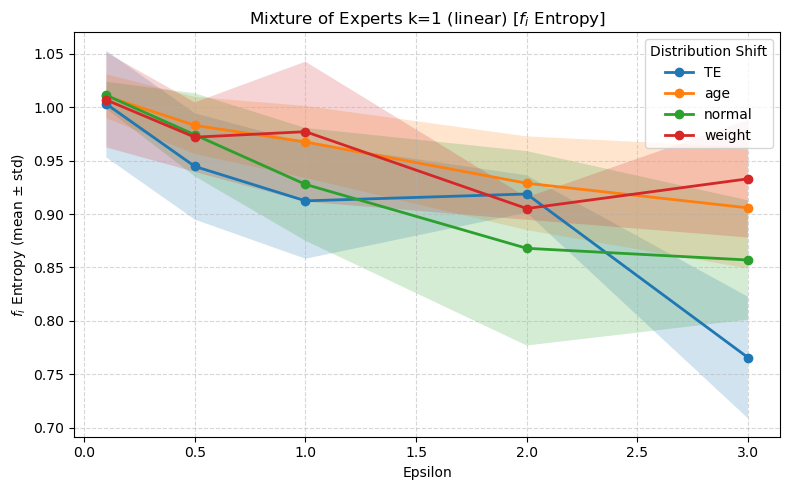

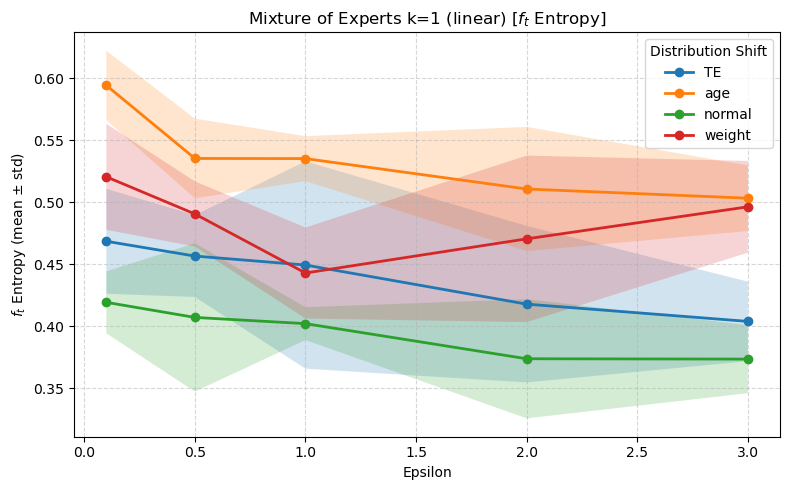

In [254]:
plot_results(path="final_dataset/MoE2-linear", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True)

## MoE k=2 MLP


Shift: TE
MoE.test.weight0 max value: 0.39267919460932416
MoE.test.weight1 max value: 0.3408753474553426
MoE.test.weight2 max value: 0.34342190623283386

Shift: age
MoE.test.weight0 max value: 0.4073382616043091
MoE.test.weight1 max value: 0.4058916966120402
MoE.test.weight2 max value: 0.3086360345284144

Shift: normal
MoE.test.weight0 max value: 0.3199845055739085
MoE.test.weight1 max value: 0.4008840223153432
MoE.test.weight2 max value: 0.3566424747308095

Shift: weight
MoE.test.weight0 max value: 0.36417939762274426
MoE.test.weight1 max value: 0.3186662296454112
MoE.test.weight2 max value: 0.411188006401062


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
0       TE     0.1         0.392679  0.099531         0.313094  0.040123   
8       TE       1         0.359405  0.060616         0.340875  0.031347   
12      TE       2         0.330618  0.074373         0.325960  0.069011   
17     age       3         0.407338  0.008679         0.370275  0.107114   
9      age       1         0.290445  0.073191         0.405892  0.017727   
1      age     0.1         0.368457  0.080691         0.322907  0.054673   
6   normal     0.5         0.319985  0.063174         0.374221  0.030721   
18  normal       3         0.262229  0.065240         0.400884  0.018374   
2   normal     0.1         0.293176  0.071717         0.350182  0.043536   
7   weight     0.5         0.364179  0.140770         0.294973  0.059762   
19  weight       3         0.296193  0.066976         0.318666  0.032898   
3   weight     0.1         0.292632  0.128722         0.296180  0.084747   

   MoE.test.weight2            
               mean       std  
0          0.294227  0.067672  
8          0.299720  0.046681  
12         0.343422  0.052774  
17         0.222386  0.099585  
9          0.303664  0.064991  
1          0.308636  0.123846  
6          0.305795  0.093851  
18         0.336887  0.066135  
2          0.356642  0.099722  
7          0.340847  0.083553  
19         0.385140  0.064905  
3          0.411188  0.097266

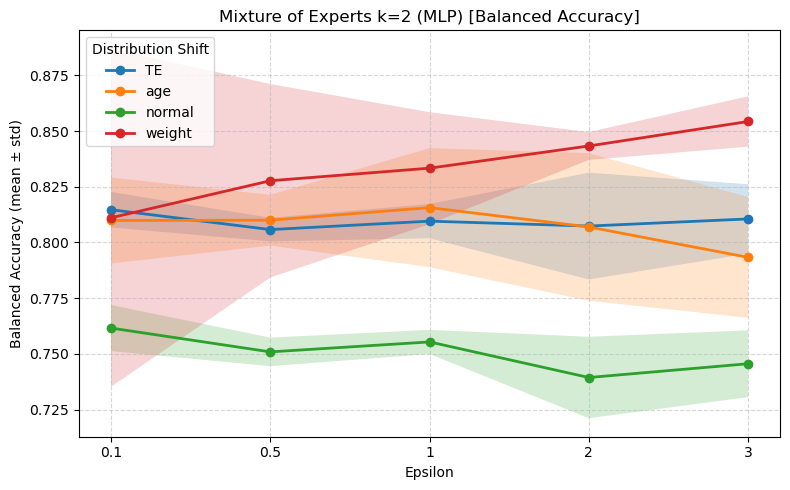

test.acc           test.balanced_acc           epsilon   Shift
        mean       std              mean       std                
0   0.844444  0.003079          0.814717  0.007950     0.1      TE
1   0.812444  0.012317          0.809879  0.019287     0.1     age
2   0.838222  0.004073          0.761576  0.010344     0.1  normal
3   0.837333  0.020133          0.811093  0.075883     0.1  weight
4   0.843556  0.005551          0.805797  0.005299     0.5      TE
5   0.817778  0.006158          0.810012  0.011398     0.5     age
6   0.833778  0.010777          0.750878  0.006420     0.5  normal
7   0.840889  0.010777          0.827729  0.043435     0.5  weight
8   0.848000  0.009615          0.809582  0.007710     1.0      TE
9   0.813333  0.009615          0.815654  0.026724     1.0     age
10  0.840000  0.009615          0.755347  0.005416     1.0  normal
11  0.839111  0.016294          0.833379  0.025127     1.0  weight
12  0.847111  0.008572          0.807376  0.023985     2.0      TE
13  0.802667  0.032332          0.806970  0.033124     2.0     age
14  0.814222  0.026309          0.739371  0.018297     2.0  normal
15  0.852444  0.006711          0.843343  0.006243     2.0  weight
16  0.845333  0.005333          0.810584  0.015585     3.0      TE
17  0.815111  0.003079          0.793319  0.027147     3.0     age
18  0.829333  0.009615          0.745561  0.014977     3.0  normal
19  0.852444  0.007698          0.854335  0.011310     3.0  weight

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.852444  0.009365          0.819313  0.012563
age     0.818667  0.016000          0.818361  0.009531
normal  0.840000  0.002667          0.752783  0.004264
weight  0.854222  0.007698          0.841267  0.022204

In [255]:
plot_results(path="final_dataset/MoE2-MLP", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=metric, title="Mixture of Experts k=2 (MLP)")

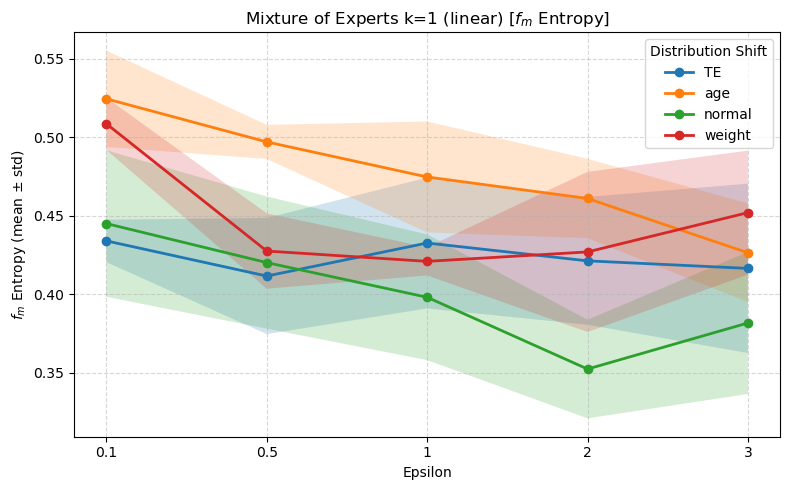

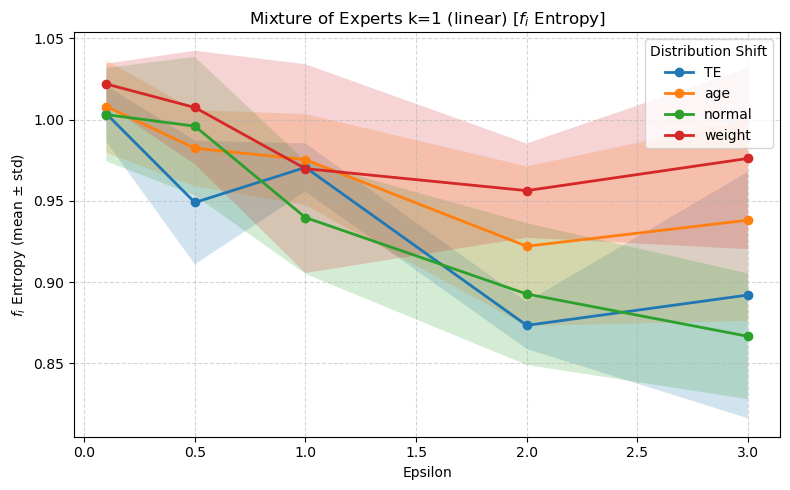

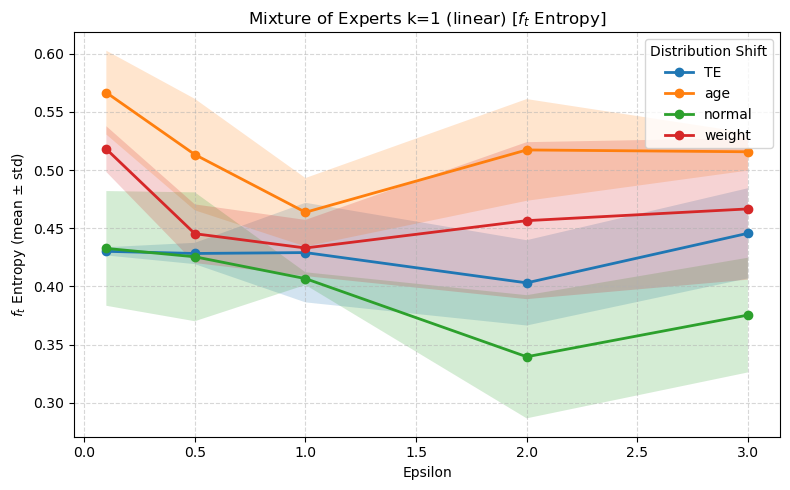

In [256]:
plot_results(path="final_dataset/MoE2-MLP", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True)

## MoE k=3 Linear


Shift: TE
MoE.test.weight0 max value: 0.37946372230847675
MoE.test.weight1 max value: 0.3237983783086141
MoE.test.weight2 max value: 0.3510879576206207

Shift: age
MoE.test.weight0 max value: 0.3576858739058177
MoE.test.weight1 max value: 0.396039754152298
MoE.test.weight2 max value: 0.34822901089986164

Shift: normal
MoE.test.weight0 max value: 0.35995422800381977
MoE.test.weight1 max value: 0.3351566791534423
MoE.test.weight2 max value: 0.3570223550001779

Shift: weight
MoE.test.weight0 max value: 0.40086983640988666
MoE.test.weight1 max value: 0.31201627850532526
MoE.test.weight2 max value: 0.38619881868362427


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
0       TE     0.1         0.379464  0.035965         0.274676  0.018437   
16      TE       3         0.349724  0.003430         0.323798  0.032796   
8       TE       1         0.349311  0.034317         0.299601  0.041790   
9      age       1         0.357686  0.046329         0.369919  0.038748   
13     age       2         0.346797  0.046579         0.396040  0.024992   
1      age     0.1         0.323641  0.022237         0.328130  0.051082   
6   normal     0.5         0.359954  0.034379         0.321594  0.038081   
10  normal       1         0.315991  0.018214         0.335157  0.019128   
14  normal       2         0.347038  0.053092         0.295939  0.047891   
15  weight       2         0.400870  0.038467         0.272450  0.053579   
19  weight       3         0.345870  0.037468         0.312016  0.039149   
3   weight     0.1         0.349962  0.027422         0.263840  0.016519   

   MoE.test.weight2            
               mean       std  
0          0.345861  0.030583  
16         0.326477  0.031327  
8          0.351088  0.029848  
9          0.272395  0.071227  
13         0.257164  0.033169  
1          0.348229  0.030598  
6          0.318452  0.007088  
10         0.348853  0.036590  
14         0.357022  0.027460  
15         0.326680  0.070185  
19         0.342114  0.023683  
3          0.386199  0.022082

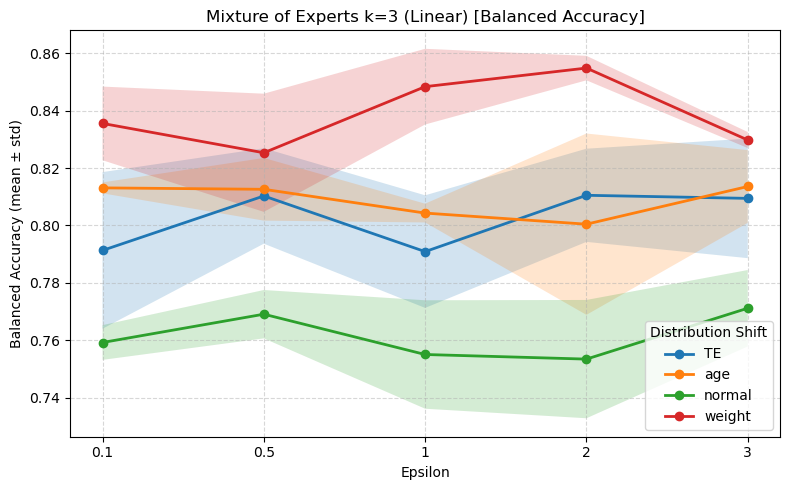

test.acc           test.balanced_acc           epsilon   Shift
        mean       std              mean       std                
0   0.848889  0.008147          0.791303  0.027286     0.1      TE
1   0.813333  0.010667          0.813093  0.001900     0.1     age
2   0.842667  0.002667          0.759218  0.006047     0.1  normal
3   0.850667  0.000000          0.835548  0.012834     0.1  weight
4   0.848889  0.004073          0.810276  0.016624     0.5      TE
5   0.808000  0.014111          0.812595  0.010916     0.5     age
6   0.835556  0.023901          0.769080  0.008427     0.5  normal
7   0.851556  0.004073          0.825321  0.020587     0.5  weight
8   0.848000  0.010667          0.790885  0.019617     1.0      TE
9   0.800000  0.000000          0.804314  0.003269     1.0     age
10  0.839111  0.011102          0.755039  0.018891     1.0  normal
11  0.852444  0.005551          0.848360  0.013185     1.0  weight
12  0.851556  0.003079          0.810509  0.016233     2.0      TE
13  0.813333  0.009615          0.800441  0.031589     2.0     age
14  0.823111  0.019291          0.753434  0.020606     2.0  normal
15  0.845333  0.016221          0.854834  0.004266     2.0  weight
16  0.853333  0.007055          0.809435  0.020826     3.0      TE
17  0.809778  0.010096          0.813573  0.012682     3.0     age
18  0.845333  0.007055          0.771162  0.013305     3.0  normal
19  0.840000  0.009238          0.829765  0.002788     3.0  weight

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.852444  0.009365          0.819313  0.012563
age     0.818667  0.016000          0.818361  0.009531
normal  0.840000  0.002667          0.752783  0.004264
weight  0.854222  0.007698          0.841267  0.022204

In [257]:
plot_results(path="final_dataset/MoE3-linear", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=metric, title="Mixture of Experts k=3 (Linear)")

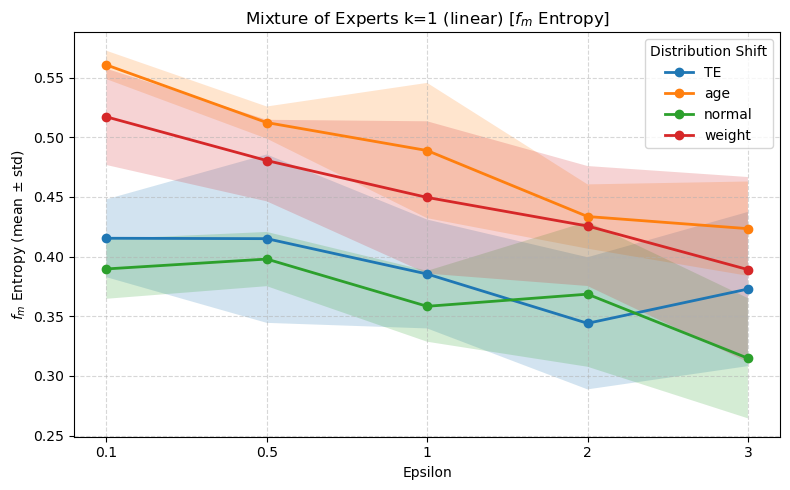

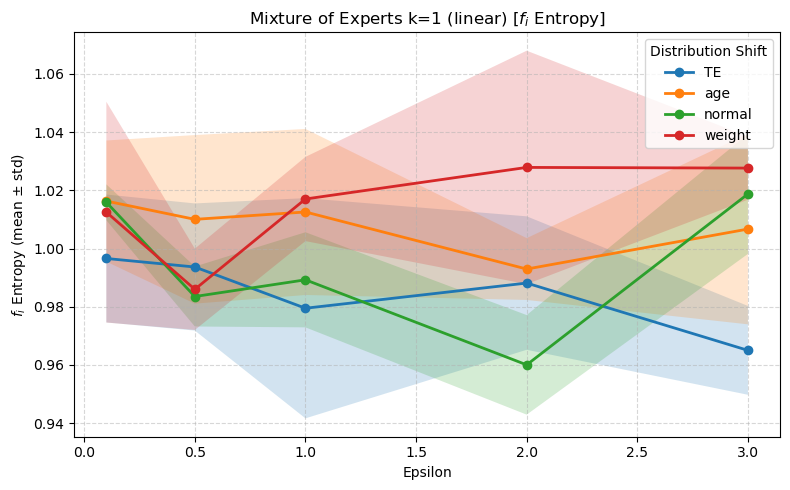

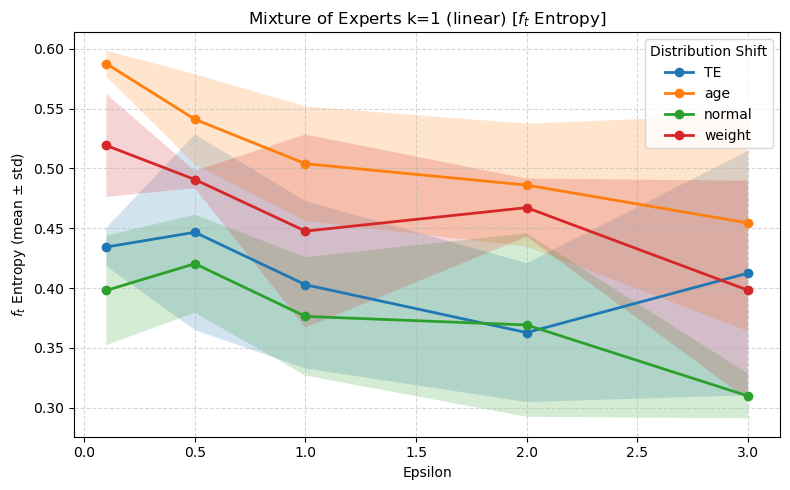

In [258]:
plot_results(path="final_dataset/MoE3-linear", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True)

## MoE k=3 MLP


Shift: TE
MoE.test.weight0 max value: 0.35298964381217957
MoE.test.weight1 max value: 0.3276186386744181
MoE.test.weight2 max value: 0.3811416029930115

Shift: age
MoE.test.weight0 max value: 0.3613846004009246
MoE.test.weight1 max value: 0.3549264073371887
MoE.test.weight2 max value: 0.33482809861501056

Shift: normal
MoE.test.weight0 max value: 0.3432638148466746
MoE.test.weight1 max value: 0.33418452739715576
MoE.test.weight2 max value: 0.34876482685407

Shift: weight
MoE.test.weight0 max value: 0.3489306370417277
MoE.test.weight1 max value: 0.30957049131393427
MoE.test.weight2 max value: 0.3793160716692607


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
16      TE       3         0.352990  0.013256         0.285852  0.015442   
12      TE       2         0.314958  0.002287         0.327619  0.025705   
4       TE     0.5         0.320128  0.031100         0.298731  0.023095   
5      age     0.5         0.361385  0.025868         0.331151  0.060494   
17     age       3         0.354469  0.014593         0.354926  0.064962   
1      age     0.1         0.360162  0.023748         0.305010  0.028300   
18  normal       3         0.343264  0.026020         0.326351  0.006096   
6   normal     0.5         0.330891  0.002010         0.334185  0.019141   
2   normal     0.1         0.328806  0.004765         0.322429  0.007045   
3   weight     0.1         0.348931  0.027161         0.294692  0.023127   
11  weight       1         0.311113  0.002339         0.309570  0.024066   
11  weight       1         0.311113  0.002339         0.309570  0.024066   

   MoE.test.weight2            
               mean       std  
16         0.361159  0.024785  
12         0.357424  0.027847  
4          0.381142  0.008650  
5          0.307465  0.078894  
17         0.290604  0.063083  
1          0.334828  0.042781  
18         0.330386  0.031981  
6          0.334925  0.017131  
2          0.348765  0.002716  
3          0.356378  0.004039  
11         0.379316  0.022455  
11         0.379316  0.022455

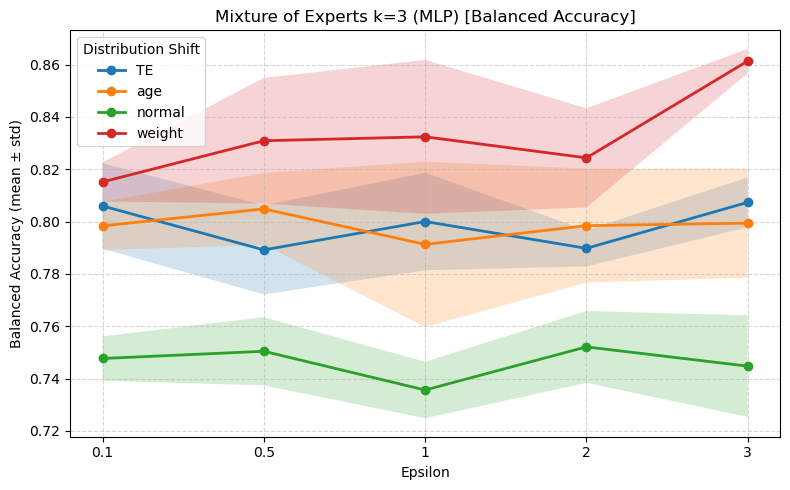

test.acc           test.balanced_acc           epsilon   Shift
        mean       std              mean       std                
0   0.853333  0.008000          0.805971  0.016335     0.1      TE
1   0.811556  0.004073          0.798358  0.009264     0.1     age
2   0.837333  0.002667          0.747680  0.008474     0.1  normal
3   0.846222  0.010777          0.815167  0.007457     0.1  weight
4   0.836444  0.008572          0.789186  0.017029     0.5      TE
5   0.808000  0.009615          0.804848  0.013708     0.5     age
6   0.837333  0.005333          0.750434  0.013029     0.5  normal
7   0.851556  0.006711          0.830897  0.024001     0.5  weight
8   0.845333  0.004619          0.800033  0.018637     1.0      TE
9   0.802667  0.014111          0.791297  0.031618     1.0     age
10  0.826667  0.009238          0.735634  0.010791     1.0  normal
11  0.856000  0.008000          0.832404  0.029409     1.0  weight
12  0.848000  0.014847          0.789775  0.006900     2.0      TE
13  0.805333  0.007055          0.798450  0.021751     2.0     age
14  0.831111  0.015625          0.752116  0.013727     2.0  normal
15  0.848889  0.012317          0.824363  0.018944     2.0  weight
16  0.847111  0.008572          0.807366  0.009519     3.0      TE
17  0.803556  0.008572          0.799407  0.020872     3.0     age
18  0.824000  0.014111          0.744755  0.019395     3.0  normal
19  0.852444  0.010096          0.861370  0.004666     3.0  weight

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.852444  0.009365          0.819313  0.012563
age     0.818667  0.016000          0.818361  0.009531
normal  0.840000  0.002667          0.752783  0.004264
weight  0.854222  0.007698          0.841267  0.022204

In [259]:
plot_results(path="final_dataset/MoE3-MLP", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=metric, title="Mixture of Experts k=3 (MLP)")

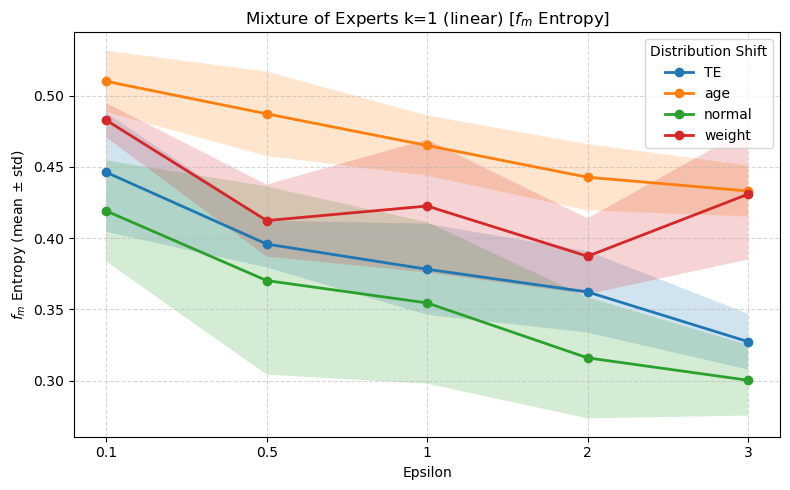

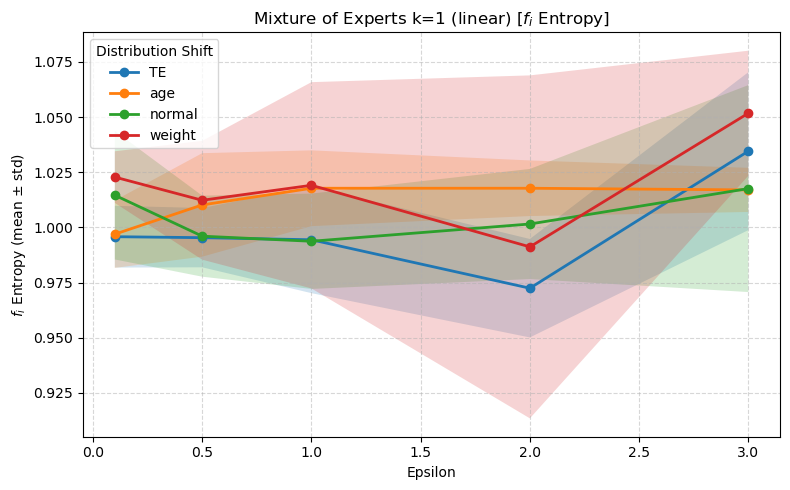

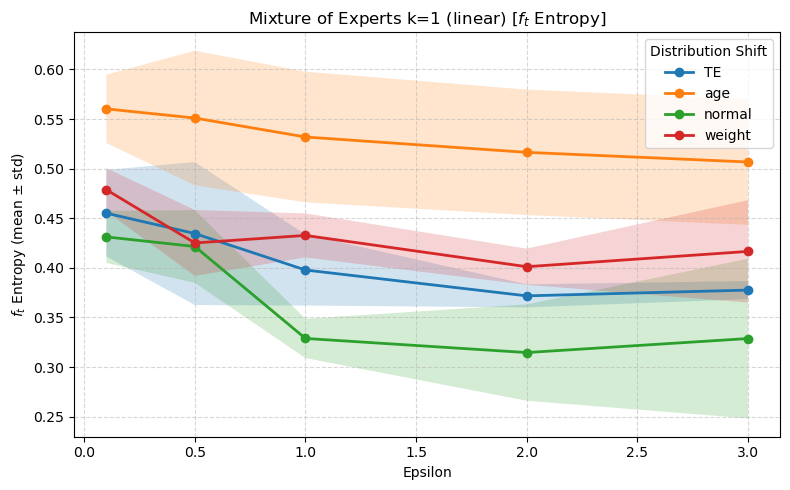

In [260]:
plot_results(path="final_dataset/MoE3-MLP", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True)

### Switch Transformer


Shift: TE
MoE.test.weight0 max value: 0.3333333432674408
MoE.test.weight1 max value: 0.3333333432674408
MoE.test.weight2 max value: 0.3333333432674408

Shift: age
MoE.test.weight0 max value: 0.3333333432674408
MoE.test.weight1 max value: 0.3333333432674408
MoE.test.weight2 max value: 0.3333333432674408

Shift: normal
MoE.test.weight0 max value: 0.3333333432674408
MoE.test.weight1 max value: 0.3333333432674408
MoE.test.weight2 max value: 0.3333333432674408

Shift: weight
MoE.test.weight0 max value: 0.3333333432674408
MoE.test.weight1 max value: 0.3333333432674408
MoE.test.weight2 max value: 0.3333333432674408


Shift epsilon MoE.test.weight0      MoE.test.weight1       \
                               mean  std             mean  std   
0       TE   0.001         0.333333  0.0         0.333333  0.0   
4       TE    0.01         0.333333  0.0         0.333333  0.0   
8       TE     0.1         0.333333  0.0         0.333333  0.0   
12      TE       2         0.333333  0.0         0.333333  0.0   
0       TE   0.001         0.333333  0.0         0.333333  0.0   
4       TE    0.01         0.333333  0.0         0.333333  0.0   
8       TE     0.1         0.333333  0.0         0.333333  0.0   
12      TE       2         0.333333  0.0         0.333333  0.0   
0       TE   0.001         0.333333  0.0         0.333333  0.0   
4       TE    0.01         0.333333  0.0         0.333333  0.0   
8       TE     0.1         0.333333  0.0         0.333333  0.0   
12      TE       2         0.333333  0.0         0.333333  0.0   
1      age   0.001         0.333333  0.0         0.333333  0.0   
5      age    0.01         0.333333  0.0         0.333333  0.0   
9      age     0.1         0.333333  0.0         0.333333  0.0   
13     age       2         0.333333  0.0         0.333333  0.0   
1      age   0.001         0.333333  0.0         0.333333  0.0   
5      age    0.01         0.333333  0.0         0.333333  0.0   
9      age     0.1         0.333333  0.0         0.333333  0.0   
13     age       2         0.333333  0.0         0.333333  0.0   
1      age   0.001         0.333333  0.0         0.333333  0.0   
5      age    0.01         0.333333  0.0         0.333333  0.0   
9      age     0.1         0.333333  0.0         0.333333  0.0   
13     age       2         0.333333  0.0         0.333333  0.0   
2   normal   0.001         0.333333  0.0         0.333333  0.0   
6   normal    0.01         0.333333  0.0         0.333333  0.0   
10  normal     0.1         0.333333  0.0         0.333333  0.0   
14  normal       2         0.333333  0.0         0.333333  0.0   
2   normal   0.001         0.333333  0.0         0.333333  0.0   
6   normal    0.01         0.333333  0.0         0.333333  0.0   
10  normal     0.1         0.333333  0.0         0.333333  0.0   
14  normal       2         0.333333  0.0         0.333333  0.0   
2   normal   0.001         0.333333  0.0         0.333333  0.0   
6   normal    0.01         0.333333  0.0         0.333333  0.0   
10  normal     0.1         0.333333  0.0         0.333333  0.0   
14  normal       2         0.333333  0.0         0.333333  0.0   
3   weight   0.001         0.333333  0.0         0.333333  0.0   
7   weight    0.01         0.333333  0.0         0.333333  0.0   
11  weight     0.1         0.333333  0.0         0.333333  0.0   
15  weight       2         0.333333  0.0         0.333333  0.0   
3   weight   0.001         0.333333  0.0         0.333333  0.0   
7   weight    0.01         0.333333  0.0         0.333333  0.0   
11  weight     0.1         0.333333  0.0         0.333333  0.0   
15  weight       2         0.333333  0.0         0.333333  0.0   
3   weight   0.001         0.333333  0.0         0.333333  0.0   
7   weight    0.01         0.333333  0.0         0.333333  0.0   
11  weight     0.1         0.333333  0.0         0.333333  0.0   
15  weight       2         0.333333  0.0         0.333333  0.0   

   MoE.test.weight2       
               mean  std  
0          0.333333  0.0  
4          0.333333  0.0  
8          0.333333  0.0  
12         0.333333  0.0  
0          0.333333  0.0  
4          0.333333  0.0  
8          0.333333  0.0  
12         0.333333  0.0  
0          0.333333  0.0  
4          0.333333  0.0  
8          0.333333  0.0  
12         0.333333  0.0  
1          0.333333  0.0  
5          0.333333  0.0  
9          0.333333  0.0  
13         0.333333  0.0  
1          0.333333  0.0  
5          0.333333  0.0  
9          0.333333  0.0  
13         0.333333  0.0  
1          0.333333  0.0  
5          0.333333  0.0  
9          0.333333  0.0  
13         0.333333  0.0  
2 

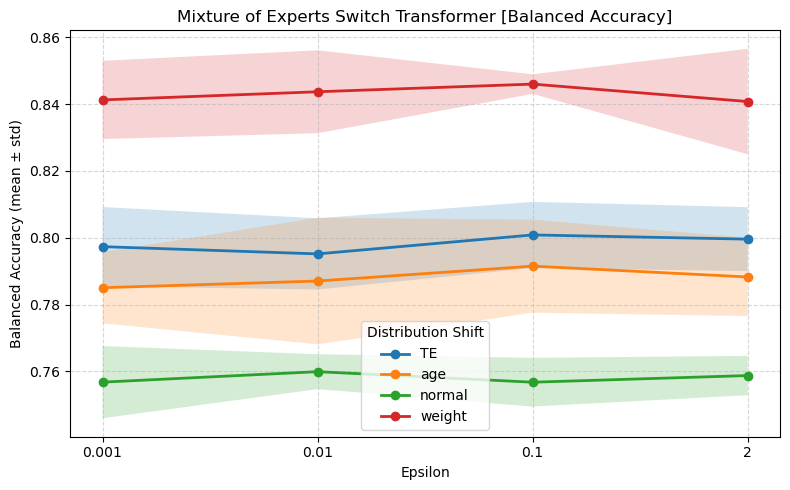

test.acc           test.balanced_acc           epsilon   Shift
        mean       std              mean       std                
0   0.850933  0.003654          0.797352  0.011853   0.001      TE
1   0.791467  0.011088          0.785066  0.010658   0.001     age
2   0.846933  0.008907          0.756813  0.010799   0.001  normal
3   0.857067  0.003373          0.841248  0.011707   0.001  weight
4   0.850667  0.004355          0.795185  0.010651   0.010      TE
5   0.795467  0.014554          0.787067  0.018942   0.010     age
6   0.849867  0.006165          0.759947  0.005222   0.010  normal
7   0.859733  0.006434          0.843690  0.012404   0.010  weight
8   0.851200  0.005451          0.800857  0.009892   0.100      TE
9   0.799200  0.007442          0.791522  0.013922   0.100     age
10  0.843733  0.012005          0.756795  0.007290   0.100  normal
11  0.860000  0.003823          0.845985  0.002933   0.100  weight
12  0.851733  0.004207          0.799596  0.009565   2.000      TE
13  0.796800  0.008127          0.788284  0.011705   2.000     age
14  0.848267  0.005822          0.758786  0.005896   2.000  normal
15  0.859200  0.006628          0.840763  0.015778   2.000  weight

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.852444  0.009365          0.819313  0.012563
age     0.818667  0.016000          0.818361  0.009531
normal  0.840000  0.002667          0.752783  0.004264
weight  0.854222  0.007698          0.841267  0.022204

In [261]:
plot_results(path="final_dataset/MoE1-Switch-NumE3", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric="test.balanced_acc", title="Mixture of Experts Switch Transformer")

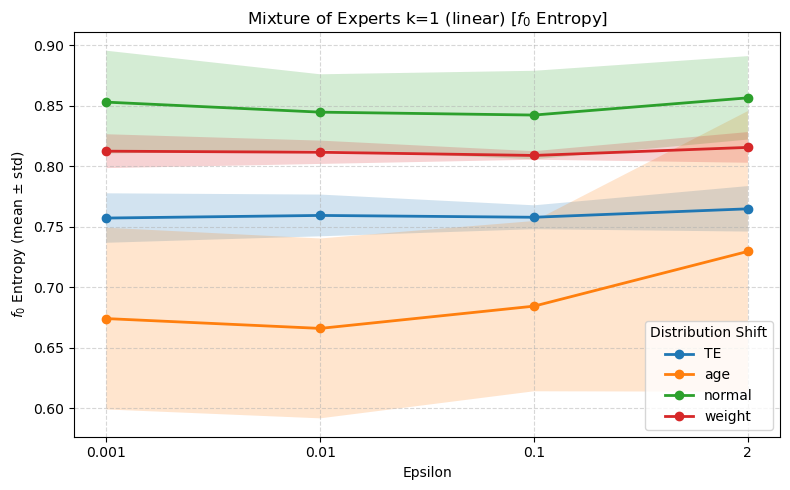

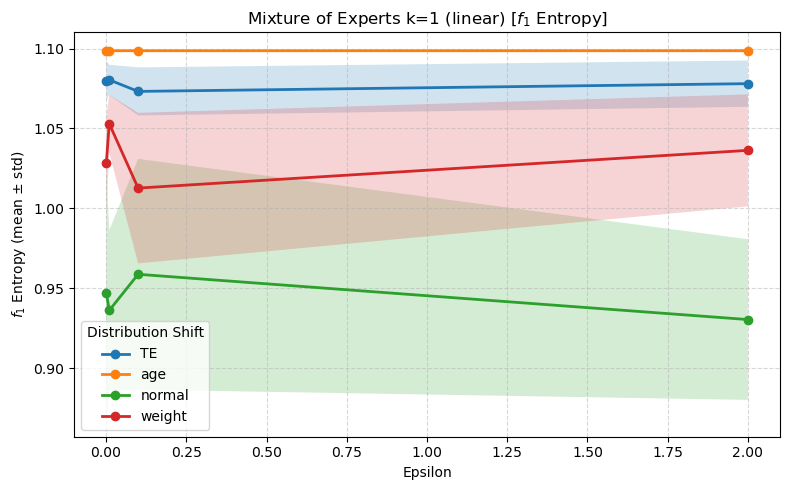

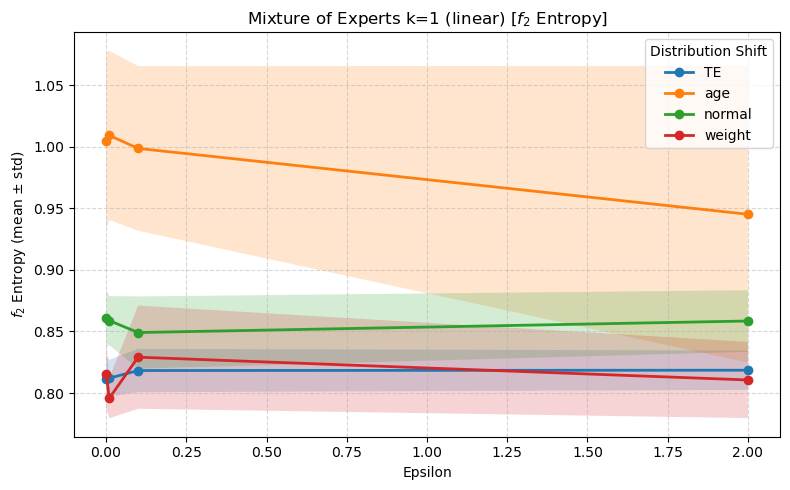

In [262]:
plot_results(path="final_dataset/MoE1-Switch-NumE3", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["test.expert_no0.entropy", "test.expert_no1.entropy", "test.expert_no2.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True)

## Latent Augmentation, all labeled

In [263]:
def summarize_please(df: pd.DataFrame):
    # Helper to convert tensors to floats
    def tensor_to_float(x):
        if isinstance(x, str):
            if "tensor" in x:
                new_x = x.strip().split("tensor(")[1][:-1]
                new_x = new_x.split(",")[0] if "," in new_x else new_x
                return float(new_x)
        return x

    # Apply conversion to all numeric-like columns
    for col in df.columns:
        df[col] = df[col].apply(tensor_to_float)
        
    display(df)

    summary_df = (
        df
        .groupby(["Shift", "Classifier", "Method"], as_index=False)
        .agg({
            **{col: "mean" for col in df.select_dtypes(include="number").columns},  # mean of numeric columns
            "Seed": lambda x: list(x)  # keep seeds as list
        })
    )
    return summary_df

In [264]:
def reshape_acc_to_csv(df, values: str, output_file="reshaped_acc.csv"):
    """
    Reshape a DataFrame of test accuracies into a CSV with columns:
    Shift, Method, $f_m$, $f_i$, $f_t$, All

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame with columns: test.acc, Classifier, Method, Shift
    output_file : str
        Path to save the resulting CSV
    """
    # Map Classifier to the target CSV columns
    col_map = {
        "multi": "$f_m$",
        "image": "$f_i$",
        "tabular": "$f_t$",
        "all": "All"
    }

    # Add a column to indicate which CSV column each row corresponds to
    df['acc_col'] = df['Classifier'].map(col_map)

    # Pivot table: rows are Shift + Method, columns are $f_m$, $f_i$, $f_t$, All
    pivot_df = df.pivot_table(
        index=['Shift', 'Method'],
        columns='acc_col',
        values=values
    ).reset_index()

    for col in ['$f_m$', '$f_i$', '$f_t$', 'All']:
        if col in pivot_df.columns:
            pivot_df[col] = (pivot_df[col].round(3) * 100).round(1)

    # Order columns
    final_cols = ['Shift', 'Method', '$f_m$', '$f_i$', '$f_t$', 'All']
    pivot_df = pivot_df.reindex(columns=final_cols)

    # Replace missing values with empty strings
    pivot_df.fillna("", inplace=True)

    # Save to CSV
    pivot_df.to_csv(output_file, index=False)
    print(f"CSV saved to {output_file}")

In [265]:
f_lat_path = os.path.join(BASE_PATH, "final_dataset/latent-augmentation-all-labeled")
df_lat = create_three_group_df(dir_path=f_lat_path, filename="eval", one_per_seed=False)
#display(df_lat)
summed_df_lat = summarize_please(df=df_lat)
#display(summed_df_lat)
#display(summed_df_lat[summed_df_lat["Classifier"] == "all"][["test.acc", "test.balanced_acc", "Shift", "Classifier", "Method"]])
#display(summed_df_lat[summed_df_lat["Classifier"] == "image"][["test.acc", "test.balanced_acc", "Shift", "Classifier", "Method"]])
#display(summed_df_lat[summed_df_lat["Classifier"] == "tabular"][["test.acc", "test.balanced_acc", "Shift", "Classifier", "Method"]])
#display(summed_df_lat[summed_df_lat["Classifier"] == "multi"][["test.acc", "test.balanced_acc", "Shift", "Classifier", "Method"]])
reshape_acc_to_csv(df=summed_df_lat[["eval.train.latent.multi.aug_rate", "eval.train.latent.image.aug_rate", "eval.train.latent.table.aug_rate", "Shift", "Classifier", "Method"]], output_file="augment_rate_image.csv", values="eval.train.latent.image.aug_rate")

,multimodal.val.ITCloss,multimodal.val.top1,multimodal.val.top5,multimodal.val.CLUBloss_imaging,multimodal.val.CLUBloss_imaging_est,multimodal.val.CLUBloss_tabular,multimodal.val.CLUBloss_tabular_est,multimodal.val.CEloss,eval.val.balanced_acc,multimodal.val.loss,...,eval.train.teacher.latent.table.aug_rate,eval.train.acc,eval.train.auc,classifier.multi.acc,classifier.image.acc,classifier.tab.acc,Shift,Classifier,Seed,Method
0,5.7042,0.0653,0.3295,0.0496,0.0930,0.0942,0.0658,0.7516,0.7660,17.4141,...,0.0000,0.9541,0.9950,0.9932,0.8555,0.9555,normal,tabular,2023,mixstyle
1,5.9908,0.0795,0.3580,0.0459,0.0757,0.1107,0.0700,0.6290,0.7922,18.2493,...,0.4959,0.9473,0.9897,0.9644,0.7219,0.9199,normal,all,2024,extrapolation
2,5.6496,0.0795,0.3523,0.0526,0.0616,0.0750,0.0464,1.1584,0.6111,17.2983,...,0.4081,0.9610,0.9952,0.9979,0.9438,0.8890,TE,tabular,2022,delta
3,4.0396,0.0540,0.2727,0.0300,0.0331,0.0457,0.0448,0.9050,0.6300,12.3767,...,0.0000,0.9267,0.9818,0.9582,0.9014,0.9281,weight,multi,2022,delta
4,5.0387,0.0881,0.3949,0.0514,0.0503,0.0892,0.0763,0.8527,0.7282,15.4204,...,0.4084,0.9781,0.9989,1.0000,0.9822,0.8719,age,tabular,2023,delta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,6.1163,0.0540,0.2955,0.0618,0.0935,0.0954,0.0713,0.5995,0.7358,18.6299,...,0.4958,0.9144,0.9806,0.9671,0.7062,0.9185,normal,all,2023,extrapolation
701,5.5543,0.0653,0.3494,0.0438,0.0547,0.0805,0.0560,0.9089,0.7284,16.9621,...,0.5000,0.9870,0.9996,1.0000,0.9932,0.9644,normal,all,2023,mixstyle
702,3.4657,0.0511,0.2500,0.0063,0.0198,0.0165,0.1503,1.1508,0.5049,10.7236,...,0.5000,0.9712,0.9968,0.9986,0.9767,0.9158,weight,all,2024,mixstyle
703,4.6087,0.0938,0.3352,0.0431,0.0553,0.0627,0.0347,0.7377,0.6839,14.0715,...,0.0000,0.9486,0.9916,0.9890,0.7103,0.9322,weight,image,2022,delta


CSV saved to augment_rate_image.csv


/tmp/ipykernel_1856418/909123541.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['acc_col'] = df['Classifier'].map(col_map)


# DVM

In [266]:
BASE_DVM_PATH = "/data/local/kgutjahr/results/test/runs/eval/DVM"

## Baseline

In [267]:
f_base_path = os.path.join(BASE_DVM_PATH, "baseline")
group_col = "epsilon"
df_c_f_base = create_one_group_df(dir_path=f_base_path, filename="test", one_per_seed=False)
#display(df_c_f_base)
summed_f_base_df = summarize_df(df=df_c_f_base, group_col="Shift")
summed_f_base_df[["test.acc", "test.balanced_acc"]]

test.acc           test.balanced_acc          
                 mean       std              mean       std
Shift                                                      
black        0.900908  0.011438          0.884244  0.012234
color_miles  0.917713  0.005891          0.891435  0.006215
miles        0.915788  0.005058          0.901881  0.006620
normal       0.966533  0.001701          0.960397  0.003545

## MoE k=3 MLP


Shift: black
MoE.test.weight0 max value: 0.3436852097511291
MoE.test.weight1 max value: 0.31471996307373046
MoE.test.weight2 max value: 0.38467564185460407

Shift: color
MoE.test.weight0 max value: 0.3433887859185536
MoE.test.weight1 max value: 0.32399666309356684
MoE.test.weight2 max value: 0.35566714406013483

Shift: miles
MoE.test.weight0 max value: 0.35897310574849445
MoE.test.weight1 max value: 0.3276483118534088
MoE.test.weight2 max value: 0.3476888835430145

Shift: normal
MoE.test.weight0 max value: 0.3333264887332916
MoE.test.weight1 max value: 0.34957337379455566
MoE.test.weight2 max value: 0.4017946620782216


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
16   black       3         0.343685  0.011415         0.292521  0.035409   
4    black     0.5         0.339699  0.014404         0.314720  0.041876   
8    black       1         0.321967  0.013604         0.293357  0.040310   
9    color       1         0.343389  0.009098         0.309632  0.022538   
13   color       2         0.333229  0.000163         0.323997  0.016426   
1    color     0.1         0.324109  0.018100         0.320224  0.026192   
18   miles       3         0.358973  0.030189         0.305363  0.027794   
2    miles     0.1         0.331975  0.002875         0.327648  0.010948   
10   miles       1         0.343885  0.026599         0.308426  0.030708   
20  normal       4         0.333326       NaN         0.333370       NaN   
11  normal       1         0.252187  0.070975         0.349573  0.014217   
19  normal       3         0.249876  0.073083         0.348329  0.013835   

   MoE.test.weight2            
               mean       std  
16         0.363794  0.027306  
4          0.345581  0.027472  
8          0.384676  0.045980  
9          0.346979  0.016849  
13         0.342775  0.016377  
1          0.355667  0.044288  
18         0.335664  0.007207  
2          0.340376  0.013819  
10         0.347689  0.012735  
20         0.333303       NaN  
11         0.398240  0.056997  
19         0.401795  0.059547

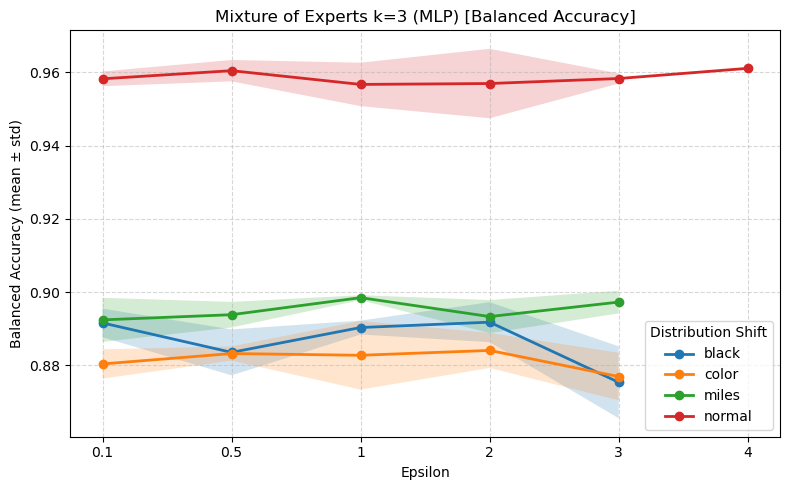

test.acc           test.balanced_acc           epsilon   Shift
        mean       std              mean       std                
0   0.909856  0.001445          0.891614  0.003911     0.1   black
1   0.912211  0.003858          0.880421  0.003989     0.1   color
2   0.909824  0.003870          0.892448  0.006013     0.1   miles
3   0.968667  0.002663          0.958243  0.002008     0.1  normal
4   0.903686  0.005306          0.883578  0.006270     0.5   black
5   0.915283  0.004373          0.883260  0.001952     0.5   color
6   0.910989  0.003822          0.893860  0.003486     0.5   miles
7   0.968240  0.002104          0.960465  0.002920     0.5  normal
8   0.905649  0.002310          0.890363  0.001890     1.0   black
9   0.911908  0.006343          0.882784  0.009361     1.0   color
10  0.912476  0.000819          0.898510  0.000665     1.0   miles
11  0.966400  0.004200          0.956710  0.005926     1.0  normal
12  0.911325  0.006143          0.891824  0.005464     2.0   black
13  0.914068  0.003823          0.884110  0.004779     2.0   color
14  0.909840  0.001467          0.893349  0.004517     2.0   miles
15  0.965867  0.006300          0.956957  0.009476     2.0  normal
16  0.898037  0.005705          0.875408  0.009812     3.0   black
17  0.908195  0.007670          0.876969  0.006500     3.0   color
18  0.910922  0.002031          0.897304  0.003096     3.0   miles
19  0.966133  0.002003          0.958324  0.001375     3.0  normal
20  0.968000       NaN          0.961101       NaN     4.0  normal

test.acc           test.balanced_acc          
                 mean       std              mean       std
Shift                                                      
black        0.900908  0.011438          0.884244  0.012234
color_miles  0.917713  0.005891          0.891435  0.006215
miles        0.915788  0.005058          0.901881  0.006620
normal       0.966533  0.001701          0.960397  0.003545

In [268]:
plot_results(path="MoE3-MLP", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric="test.balanced_acc", title="Mixture of Experts k=3 (MLP)", base_path=BASE_DVM_PATH, pattern=r"MoE_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_|dvm_all_server_reordered_SemiPseudo_TIP)_([a-zA-Z]+)_(?:seed)?")

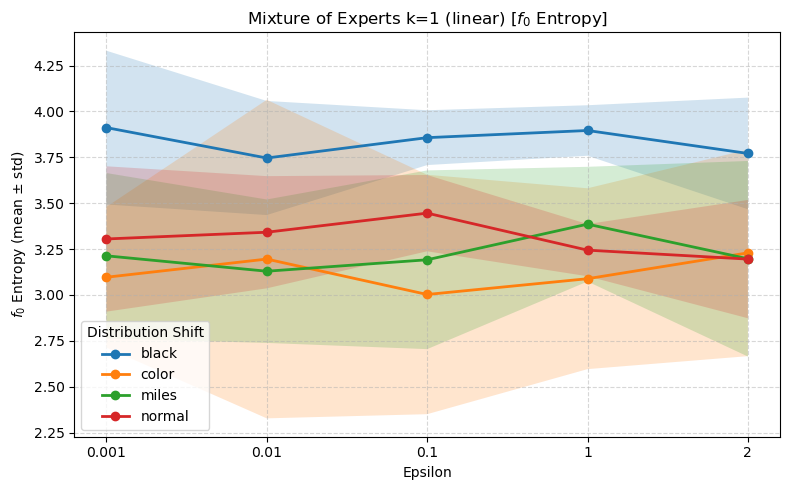

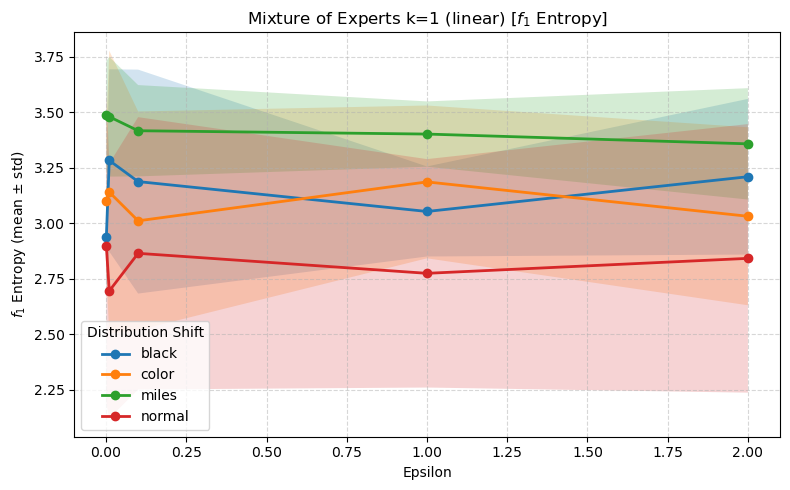

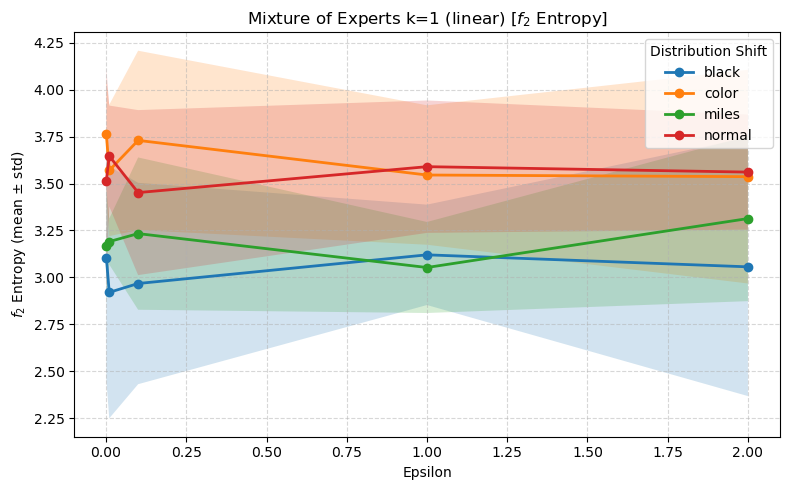

In [270]:
plot_results(path="MoE1-MLP-Switch", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", base_path=BASE_DVM_PATH, metric=["test.expert_no0.entropy", "test.expert_no1.entropy", "test.expert_no2.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True, pattern=r"MoE_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_|dvm_all_server_reordered_SemiPseudo_TIP)_([a-zA-Z]+)_(?:seed)?")

## MoE k=1 Swift


Shift: black
MoE.test.weight0 max value: 0.3436852097511291
MoE.test.weight1 max value: 0.31471996307373046
MoE.test.weight2 max value: 0.38467564185460407

Shift: color
MoE.test.weight0 max value: 0.3433887859185536
MoE.test.weight1 max value: 0.32399666309356684
MoE.test.weight2 max value: 0.35566714406013483

Shift: miles
MoE.test.weight0 max value: 0.35897310574849445
MoE.test.weight1 max value: 0.3276483118534088
MoE.test.weight2 max value: 0.3476888835430145

Shift: normal
MoE.test.weight0 max value: 0.3333264887332916
MoE.test.weight1 max value: 0.34957337379455566
MoE.test.weight2 max value: 0.4017946620782216


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
16   black       3         0.343685  0.011415         0.292521  0.035409   
4    black     0.5         0.339699  0.014404         0.314720  0.041876   
8    black       1         0.321967  0.013604         0.293357  0.040310   
9    color       1         0.343389  0.009098         0.309632  0.022538   
13   color       2         0.333229  0.000163         0.323997  0.016426   
1    color     0.1         0.324109  0.018100         0.320224  0.026192   
18   miles       3         0.358973  0.030189         0.305363  0.027794   
2    miles     0.1         0.331975  0.002875         0.327648  0.010948   
10   miles       1         0.343885  0.026599         0.308426  0.030708   
20  normal       4         0.333326       NaN         0.333370       NaN   
11  normal       1         0.252187  0.070975         0.349573  0.014217   
19  normal       3         0.249876  0.073083         0.348329  0.013835   

   MoE.test.weight2            
               mean       std  
16         0.363794  0.027306  
4          0.345581  0.027472  
8          0.384676  0.045980  
9          0.346979  0.016849  
13         0.342775  0.016377  
1          0.355667  0.044288  
18         0.335664  0.007207  
2          0.340376  0.013819  
10         0.347689  0.012735  
20         0.333303       NaN  
11         0.398240  0.056997  
19         0.401795  0.059547

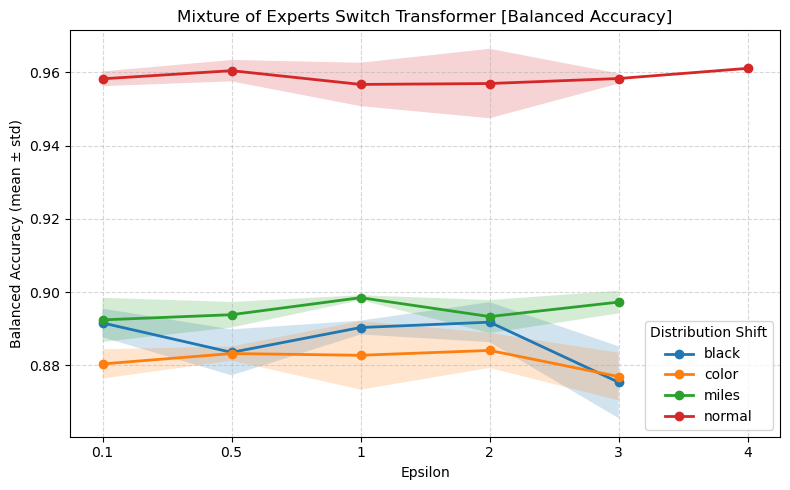

test.acc           test.balanced_acc           epsilon   Shift
        mean       std              mean       std                
0   0.909856  0.001445          0.891614  0.003911     0.1   black
1   0.912211  0.003858          0.880421  0.003989     0.1   color
2   0.909824  0.003870          0.892448  0.006013     0.1   miles
3   0.968667  0.002663          0.958243  0.002008     0.1  normal
4   0.903686  0.005306          0.883578  0.006270     0.5   black
5   0.915283  0.004373          0.883260  0.001952     0.5   color
6   0.910989  0.003822          0.893860  0.003486     0.5   miles
7   0.968240  0.002104          0.960465  0.002920     0.5  normal
8   0.905649  0.002310          0.890363  0.001890     1.0   black
9   0.911908  0.006343          0.882784  0.009361     1.0   color
10  0.912476  0.000819          0.898510  0.000665     1.0   miles
11  0.966400  0.004200          0.956710  0.005926     1.0  normal
12  0.911325  0.006143          0.891824  0.005464     2.0   black
13  0.914068  0.003823          0.884110  0.004779     2.0   color
14  0.909840  0.001467          0.893349  0.004517     2.0   miles
15  0.965867  0.006300          0.956957  0.009476     2.0  normal
16  0.898037  0.005705          0.875408  0.009812     3.0   black
17  0.908195  0.007670          0.876969  0.006500     3.0   color
18  0.910922  0.002031          0.897304  0.003096     3.0   miles
19  0.966133  0.002003          0.958324  0.001375     3.0  normal
20  0.968000       NaN          0.961101       NaN     4.0  normal

test.acc           test.balanced_acc          
                 mean       std              mean       std
Shift                                                      
black        0.900908  0.011438          0.884244  0.012234
color_miles  0.917713  0.005891          0.891435  0.006215
miles        0.915788  0.005058          0.901881  0.006620
normal       0.966533  0.001701          0.960397  0.003545

In [271]:
plot_results(path="MoE3-MLP", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric="test.balanced_acc", title="Mixture of Experts Switch Transformer", base_path=BASE_DVM_PATH, pattern=r"MoE_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_|dvm_all_server_reordered_SemiPseudo_TIP)_([a-zA-Z]+)_(?:seed)?")

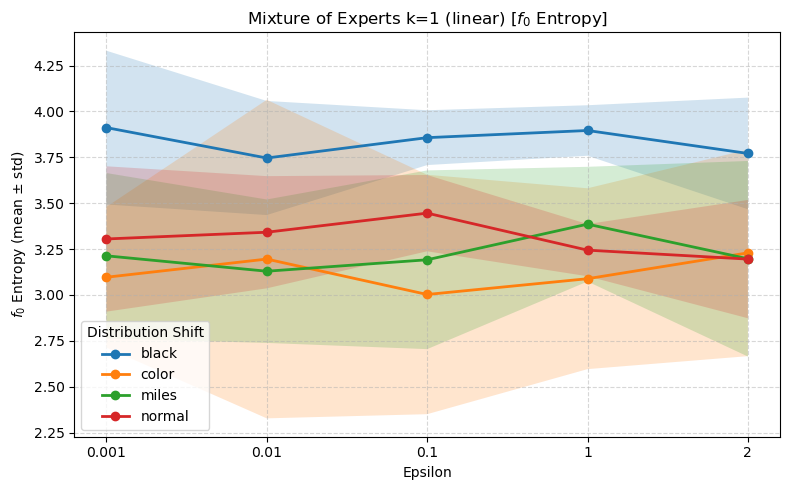

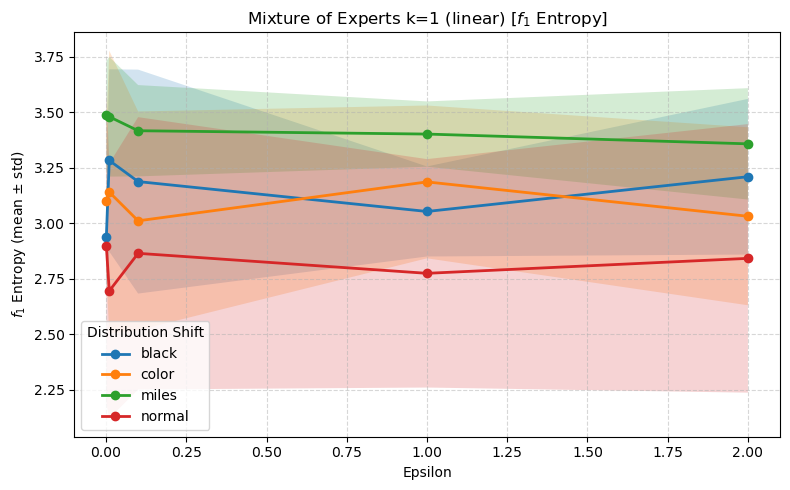

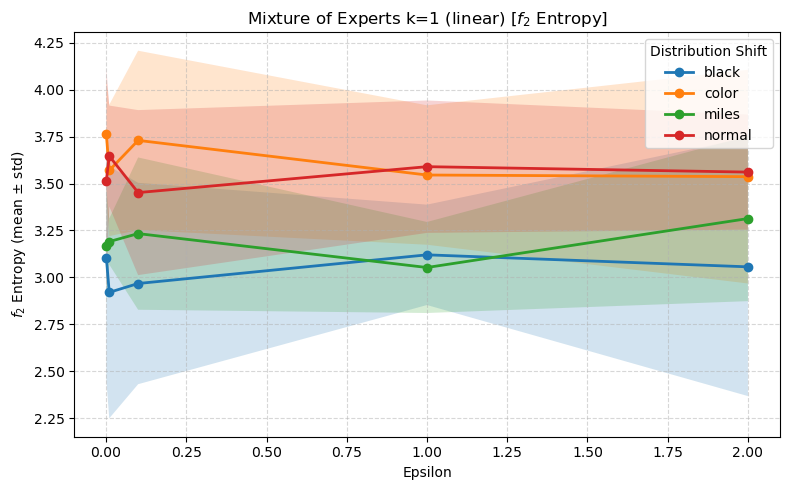

In [273]:
plot_results(path="MoE1-MLP-Switch", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", base_path=BASE_DVM_PATH, metric=["test.expert_no0.entropy", "test.expert_no1.entropy", "test.expert_no2.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True, pattern=r"MoE_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_|dvm_all_server_reordered_SemiPseudo_TIP)_([a-zA-Z]+)_(?:seed)?")